In [15]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

RAW_DIR = Path("raw")
if not RAW_DIR.exists() and Path("data/raw").exists():
    RAW_DIR = Path("data/raw")

OUTPUT_DIR = Path("eda_outputs/raw")
FIGURES_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def display_section(title, subtitle=None):
    print("\n" + "=" * 88)
    print(title)
    if subtitle:
        print(subtitle)
    print("=" * 88)

def save_table(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path

def save_text(text, filename):
    path = OUTPUT_DIR / filename
    path.write_text(text, encoding="utf-8")
    return path

def save_figure(fig, filename):
    path = FIGURES_DIR / filename
    fig.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    return path

def clean_common_columns(df):
    cleaned = df.copy()
    cleaned.columns = cleaned.columns.str.strip()
    if "province_name" in cleaned.columns:
        cleaned["province_name"] = cleaned["province_name"].astype("string").str.strip()
    if "year" in cleaned.columns:
        cleaned["year"] = pd.to_numeric(cleaned["year"], errors="coerce").astype("Int64")
    if "month" in cleaned.columns:
        cleaned["month"] = pd.to_numeric(cleaned["month"], errors="coerce").astype("Int64")
    if "date" in cleaned.columns:
        cleaned["date"] = pd.to_datetime(cleaned["date"], errors="coerce")
    return cleaned

def missing_value_report(df, dataset_name):
    report = pd.DataFrame({
        "dataset": dataset_name,
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "missing_count": df.isna().sum().values,
        "missing_percentage": (df.isna().mean() * 100).values,
        "unique_count": df.nunique(dropna=True).values,
    })
    return report

def duplicate_key_report(df, dataset_name, key_cols):
    return pd.DataFrame([{
        "dataset": dataset_name,
        "key_columns": " + ".join(key_cols),
        "total_rows": len(df),
        "duplicate_full_rows": int(df.duplicated().sum()),
        "duplicate_key_rows": int(df.duplicated(subset=key_cols).sum()),
        "duplicate_key_percentage": float(df.duplicated(subset=key_cols).mean() * 100),
    }])

def numeric_summary(df, dataset_name, numeric_cols):
    rows = []
    for column in numeric_cols:
        series = pd.to_numeric(df[column], errors="coerce")
        rows.append({
            "dataset": dataset_name,
            "column": column,
            "count": int(series.count()),
            "mean": series.mean(),
            "median": series.median(),
            "std": series.std(),
            "min": series.min(),
            "p05": series.quantile(0.05),
            "p25": series.quantile(0.25),
            "p75": series.quantile(0.75),
            "p95": series.quantile(0.95),
            "max": series.max(),
        })
    return pd.DataFrame(rows)

def iqr_outlier_report(df, dataset_name, numeric_cols):
    rows = []
    for column in numeric_cols:
        series = pd.to_numeric(df[column], errors="coerce")
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_mask = series.lt(lower_bound) | series.gt(upper_bound)
        outlier_count = int(outlier_mask.sum())
        rows.append({
            "dataset": dataset_name,
            "column": column,
            "q1": q1,
            "q3": q3,
            "iqr": iqr,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "outlier_count": outlier_count,
            "outlier_percentage": float(outlier_mask.mean() * 100),
        })
    return pd.DataFrame(rows)

def plot_hist_and_box(df, column, dataset_name):
    series = pd.to_numeric(df[column], errors="coerce").dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.histplot(series, kde=True, ax=axes[0], color="#4c72b0")
    axes[0].set_title(f"{dataset_name}: distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Count")
    sns.boxplot(x=series, ax=axes[1], color="#dd8452")
    axes[1].set_title(f"{dataset_name}: boxplot of {column}")
    axes[1].set_xlabel(column)
    plt.tight_layout()
    return fig

def plot_top_bottom_records(df, value_col, label_cols, dataset_name):
    top = df.sort_values(value_col, ascending=False).head(10)[label_cols + [value_col]]
    bottom = df.sort_values(value_col, ascending=True).head(10)[label_cols + [value_col]]
    print(f"Top 10 highest records - {dataset_name} ({value_col})")
    display(top)
    print(f"Top 10 lowest records - {dataset_name} ({value_col})")
    display(bottom)
    return top, bottom

def monthly_completeness(df):
    provinces = sorted(df["province_name"].dropna().unique())
    dates = pd.date_range(df["date"].min(), df["date"].max(), freq="MS")
    expected = pd.MultiIndex.from_product([provinces, dates], names=["province_name", "date"])
    actual = pd.MultiIndex.from_frame(df[["province_name", "date"]].dropna().drop_duplicates())
    missing = expected.difference(actual)
    return len(expected), len(actual), len(missing), missing

def annual_completeness(df):
    provinces = sorted(df["province_name"].dropna().unique())
    years = range(int(df["year"].min()), int(df["year"].max()) + 1)
    expected = pd.MultiIndex.from_product([provinces, years], names=["province_name", "year"])
    actual = pd.MultiIndex.from_frame(df[["province_name", "year"]].dropna().drop_duplicates())
    missing = expected.difference(actual)
    return len(expected), len(actual), len(missing), missing

def static_completeness(df):
    provinces = sorted(df["province_name"].dropna().unique())
    actual = int(df[["province_name"]].dropna().drop_duplicates().shape[0])
    expected = len(provinces)
    return expected, actual, expected - actual

def province_list_report(datasets):
    rows = []
    for name, df in datasets.items():
        provinces = sorted(df["province_name"].dropna().unique().tolist())
        rows.append({"dataset": name, "number_of_provinces": len(provinces), "province_list": "; ".join(provinces)})
    return pd.DataFrame(rows)

def province_membership_matrix(datasets):
    all_provinces = sorted(set.union(*[set(df["province_name"].dropna().unique()) for df in datasets.values()]))
    matrix = pd.DataFrame({"province_name": all_provinces})
    for name, df in datasets.items():
        matrix[f"in_{name}"] = matrix["province_name"].isin(df["province_name"].dropna().unique())
    return matrix

def year_bounds(df):
    if "year" in df.columns and df["year"].notna().any():
        return int(df["year"].min()), int(df["year"].max())
    return None, None

def date_bounds(df):
    if "date" in df.columns and df["date"].notna().any():
        return df["date"].min(), df["date"].max()
    return None, None

In [16]:
rainfall_df = clean_common_columns(pd.read_csv(RAW_DIR / "mekong_province_month_rainfall_1981_2025.csv"))
cropland_df = clean_common_columns(pd.read_csv(RAW_DIR / "mekong_province_cropland_2021.csv"))
water_df = clean_common_columns(pd.read_csv(RAW_DIR / "mekong_province_month_water_1984_2021.csv"))
population_df = clean_common_columns(pd.read_csv(RAW_DIR / "mekong_province_population_2000_2021.csv"))

datasets = {
    "rainfall": rainfall_df,
    "cropland": cropland_df,
    "water": water_df,
    "population": population_df,
}

key_map = {
    "rainfall": ["province_name", "year", "month"],
    "cropland": ["province_name", "year"],
    "water": ["province_name", "year", "month"],
    "population": ["province_name", "year"],
}

numeric_map = {
    "rainfall": ["rainfall_mm"],
    "cropland": ["province_area_km2", "cropland_area_km2", "cropland_pct"],
    "water": ["water_area_km2", "water_area_pct", "province_area_km2"],
    "population": ["population_total", "population_density_per_km2", "province_area_km2"],
}

profiles = []
missing_reports = []
duplicate_reports = []
numeric_reports = []
outlier_reports = []

for name, df in datasets.items():
    print(f"{name}: shape = {df.shape}")
    if "date" in df.columns:
        min_date, max_date = date_bounds(df)
        min_year, max_year = year_bounds(df)
        grain = "monthly" if name in ["rainfall", "water"] else "annual"
    else:
        min_date, max_date = None, None
        min_year, max_year = year_bounds(df)
        grain = "static"
    profiles.append({
        "dataset": name,
        "grain": grain,
        "rows": len(df),
        "columns": df.shape[1],
        "number_of_provinces": int(df["province_name"].nunique(dropna=True)),
        "min_year": min_year,
        "max_year": max_year,
        "min_date": min_date,
        "max_date": max_date,
        "duplicate_full_rows": int(df.duplicated().sum()),
        "duplicate_key_rows": int(df.duplicated(subset=key_map[name]).sum()),
        "missing_cells": int(df.isna().sum().sum()),
    })

    missing_reports.append(missing_value_report(df, name))
    duplicate_reports.append(duplicate_key_report(df, name, key_map[name]))
    numeric_reports.append(numeric_summary(df, name, numeric_map[name]))
    outlier_reports.append(iqr_outlier_report(df, name, numeric_map[name]))

profiles_df = pd.DataFrame(profiles)
missing_report_df = pd.concat(missing_reports, ignore_index=True)
duplicate_report_df = pd.concat(duplicate_reports, ignore_index=True)
numeric_summary_df = pd.concat(numeric_reports, ignore_index=True)
iqr_outlier_df = pd.concat(outlier_reports, ignore_index=True)

save_table(profiles_df, "raw_dataset_profiles.csv")
save_table(missing_report_df, "raw_missing_value_report.csv")
save_table(duplicate_report_df, "raw_duplicate_key_report.csv")
save_table(numeric_summary_df, "raw_numeric_summary.csv")
save_table(iqr_outlier_df, "raw_iqr_outlier_report.csv")

display(profiles_df)
display(missing_report_df.head(20))
display(duplicate_report_df)
display(numeric_summary_df)
display(iqr_outlier_df)

rainfall: shape = (7020, 5)
cropland: shape = (13, 5)
water: shape = (5902, 7)
population: shape = (273, 6)


,dataset,grain,rows,columns,number_of_provinces,min_year,max_year,min_date,max_date,duplicate_full_rows,duplicate_key_rows,missing_cells
0,rainfall,monthly,7020,5,13,1981,2025,1981-01-01,2025-12-01,0,0,0
1,cropland,static,13,5,13,2021,2021,NaT,NaT,0,0,0
2,water,monthly,5902,7,13,1984,2021,1984-03-01,2021-12-01,0,0,0
3,population,annual,273,6,13,2000,2020,2000-01-01,2020-01-01,0,0,0


,dataset,column,dtype,missing_count,missing_percentage,unique_count
0,rainfall,province_name,string,0,0.000,13
1,rainfall,year,Int64,0,0.000,45
2,rainfall,month,Int64,0,0.000,12
3,rainfall,date,datetime64[ns],0,0.000,540
4,rainfall,rainfall_mm,float64,0,0.000,6995
5,cropland,province_name,string,0,0.000,13
6,cropland,year,Int64,0,0.000,1
7,cropland,province_area_km2,float64,0,0.000,13
8,cropland,cropland_area_km2,float64,0,0.000,13
9,cropland,cropland_pct,float64,0,0.000,13


,dataset,key_columns,total_rows,duplicate_full_rows,duplicate_key_rows,duplicate_key_percentage
0,rainfall,province_name + year + month,7020,0,0,0.000
1,cropland,province_name + year,13,0,0,0.000
2,water,province_name + year + month,5902,0,0,0.000
3,population,province_name + year,273,0,0,0.000


,dataset,column,count,mean,median,std,min,p05,p25,p75,p95,max
0,rainfall,rainfall_mm,7020,140.419,144.047,115.229,0.000,2.873,19.572,231.432,325.952,559.464
1,cropland,province_area_km2,13,"3,109.212","2,610.874","1,480.690","1,398.217","1,480.078","2,254.440","3,540.966","5,629.231","6,294.256"
2,cropland,cropland_area_km2,13,"1,501.872","1,080.987","1,000.410",213.475,454.997,869.755,"2,180.707","3,104.638","3,560.913"
3,cropland,cropland_pct,13,47.381,54.500,18.422,9.309,16.230,40.010,62.205,67.583,72.558
4,water,water_area_km2,5902,194.756,56.649,343.393,0.000,0.000,0.000,232.640,937.535,"2,373.767"
5,water,water_area_pct,5902,6.039,2.128,9.615,0.000,0.000,0.000,8.128,25.810,67.604
6,water,province_area_km2,5902,"3,109.212","2,610.874","1,422.722","1,398.217","1,398.217","2,254.440","3,540.966","6,294.256","6,294.256"
7,population,population_total,273,"1,139,592.017","1,087,615.154","320,739.048","637,849.866","687,976.134","880,185.497","1,384,804.022","1,819,250.458","1,941,790.182"
8,population,population_density_per_km2,273,418.123,404.587,153.279,185.946,201.457,291.046,535.455,659.847,876.063
9,population,province_area_km2,273,"3,109.212","2,610.874","1,425.214","1,398.217","1,398.217","2,254.440","3,540.966","6,294.256","6,294.256"


,dataset,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,rainfall,rainfall_mm,19.572,231.432,211.859,-298.217,549.220,2,0.028
1,cropland,province_area_km2,"2,254.440","3,540.966","1,286.526",324.651,"5,470.755",1,7.692
2,cropland,cropland_area_km2,869.755,"2,180.707","1,310.953","-1,096.675","4,147.136",0,0.000
3,cropland,cropland_pct,40.010,62.205,22.194,6.719,95.496,0,0.000
4,water,water_area_km2,0.000,232.640,232.640,-348.960,581.600,569,9.641
5,water,water_area_pct,0.000,8.128,8.128,-12.191,20.319,444,7.523
6,water,province_area_km2,"2,254.440","3,540.966","1,286.526",324.651,"5,470.755",454,7.692
7,population,population_total,"880,185.497","1,384,804.022","504,618.525","123,257.709","2,141,731.810",0,0.000
8,population,population_density_per_km2,291.046,535.455,244.409,-75.567,902.068,0,0.000
9,population,province_area_km2,"2,254.440","3,540.966","1,286.526",324.651,"5,470.755",21,7.692


In [17]:
# ## 1. Rainfall EDA

# This section reviews monthly rainfall as the main time-varying climate driver. The checks focus on completeness, duplicate keys, plausibility, seasonality, and extreme values.


Rainfall EDA
Monthly province-level rainfall from 1981-2025


,dataset,column,dtype,missing_count,missing_percentage,unique_count
0,rainfall,province_name,string,0,0.000,13
1,rainfall,year,Int64,0,0.000,45
2,rainfall,month,Int64,0,0.000,12
3,rainfall,date,datetime64[ns],0,0.000,540
4,rainfall,rainfall_mm,float64,0,0.000,6995
5,rainfall,season,object,0,0.000,2


,dataset,key_columns,total_rows,duplicate_full_rows,duplicate_key_rows,duplicate_key_percentage
0,rainfall,province_name + year + month,7020,0,0,0.000


,check,value
0,invalid month rows,0
1,negative rainfall rows,0
2,rainfall > 500 mm rows,11
3,rainfall > IQR upper bound rows,2


,dataset,column,count,mean,median,std,min,p05,p25,p75,p95,max
0,rainfall,rainfall_mm,7020,140.419,144.047,115.229,0.000,2.873,19.572,231.432,325.952,559.464


,dataset,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,rainfall,rainfall_mm,19.572,231.432,211.859,-298.217,549.220,2,0.028


Actual min year: 1981
Actual max year: 2025
Actual min date: 1981-01-01 00:00:00
Actual max date: 2025-12-01 00:00:00
Number of provinces: 13


,province_name,record_count
0,An Giang,540
1,Bac Lieu,540
2,Ben Tre,540
3,Ca Mau,540
4,Can Tho city,540
5,Dong Thap,540
6,Hau Giang,540
7,Kien Giang,540
8,Long An,540
9,Soc Trang,540


,province_name,year,month_count,record_count
0,An Giang,1981,12,12
1,An Giang,1982,12,12
2,An Giang,1983,12,12
3,An Giang,1984,12,12
4,An Giang,1985,12,12
5,An Giang,1986,12,12
6,An Giang,1987,12,12
7,An Giang,1988,12,12
8,An Giang,1989,12,12
9,An Giang,1990,12,12


,province_name,year,month


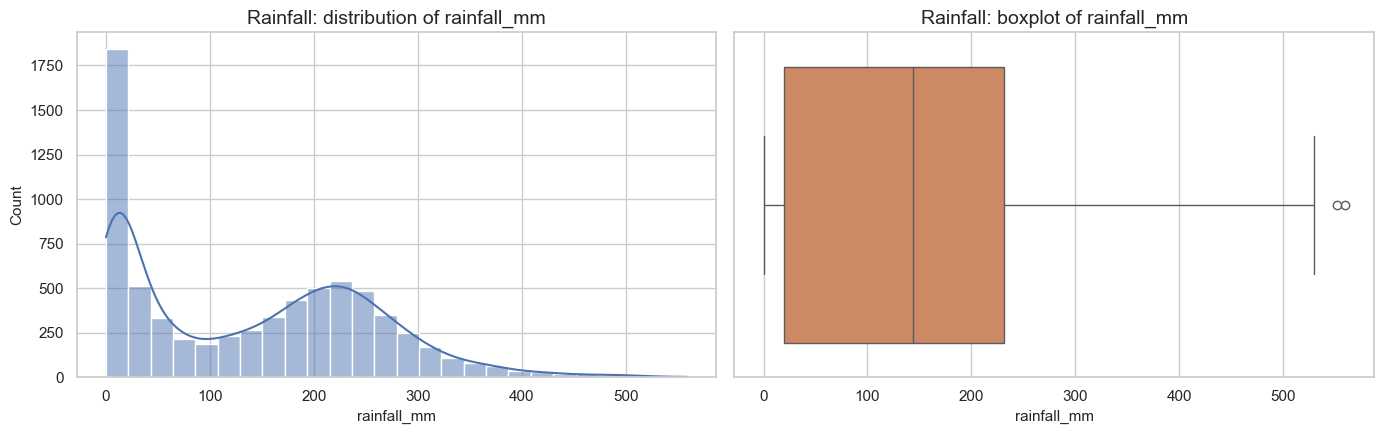

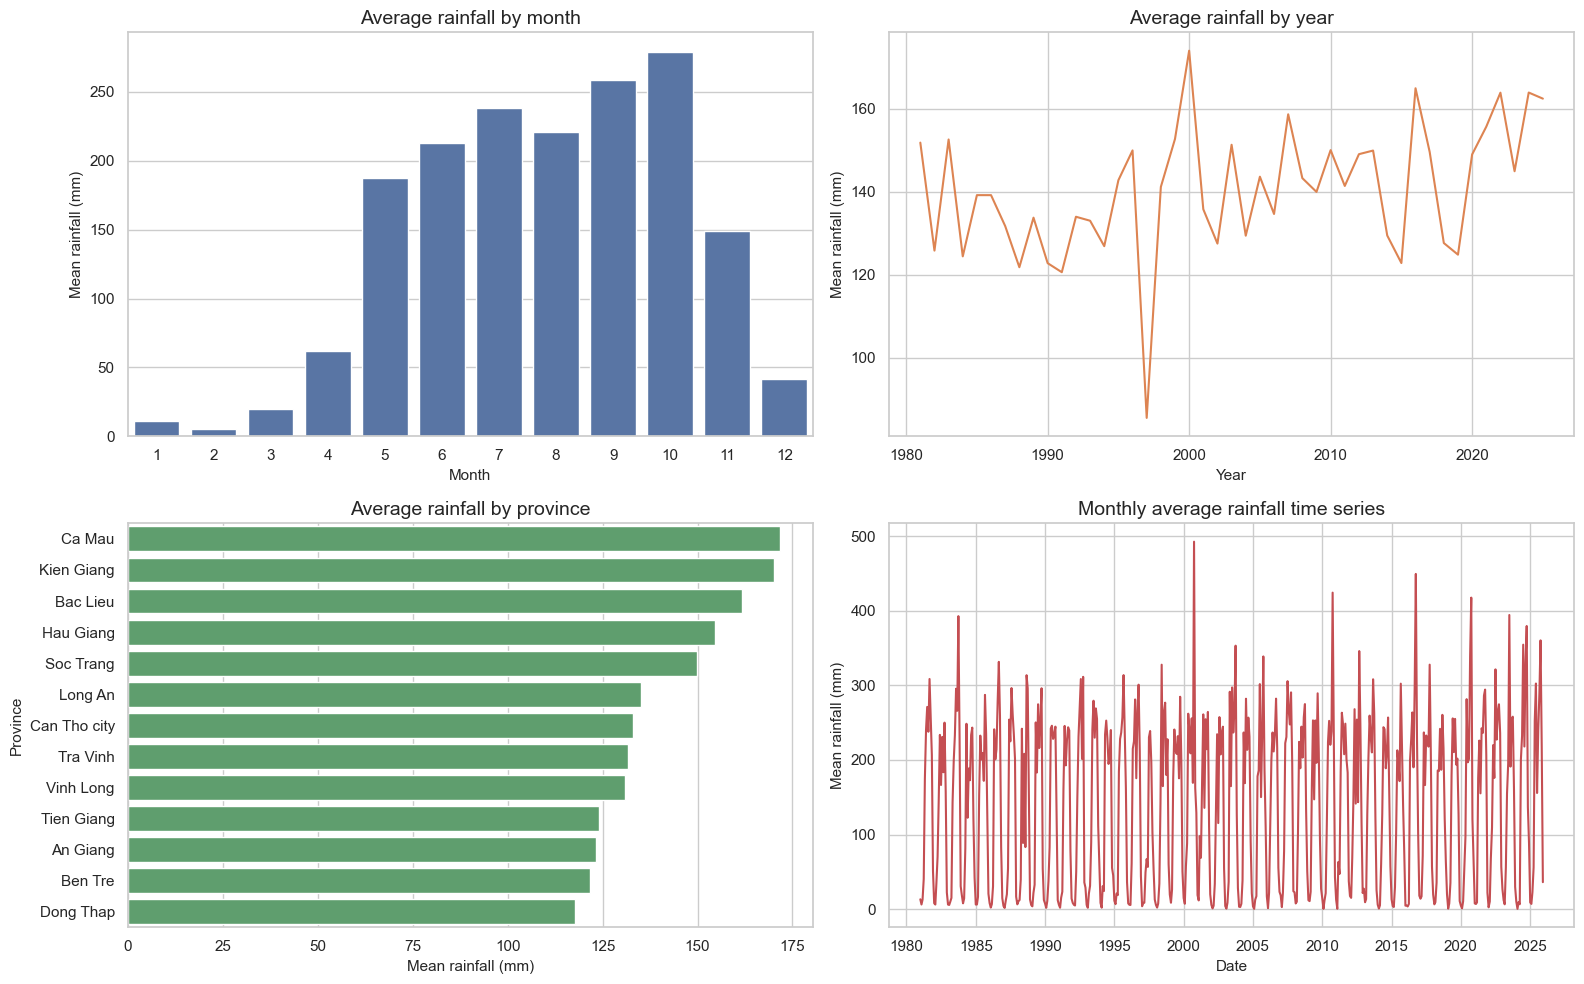

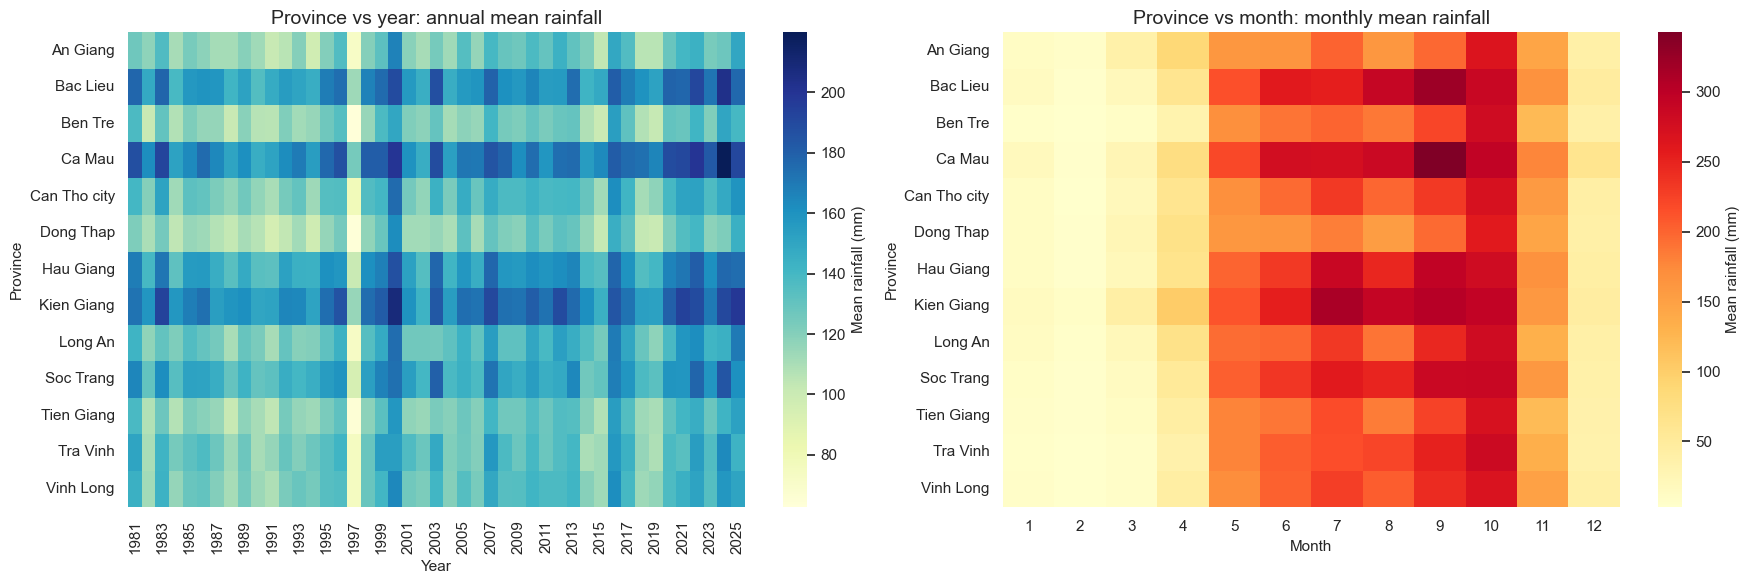

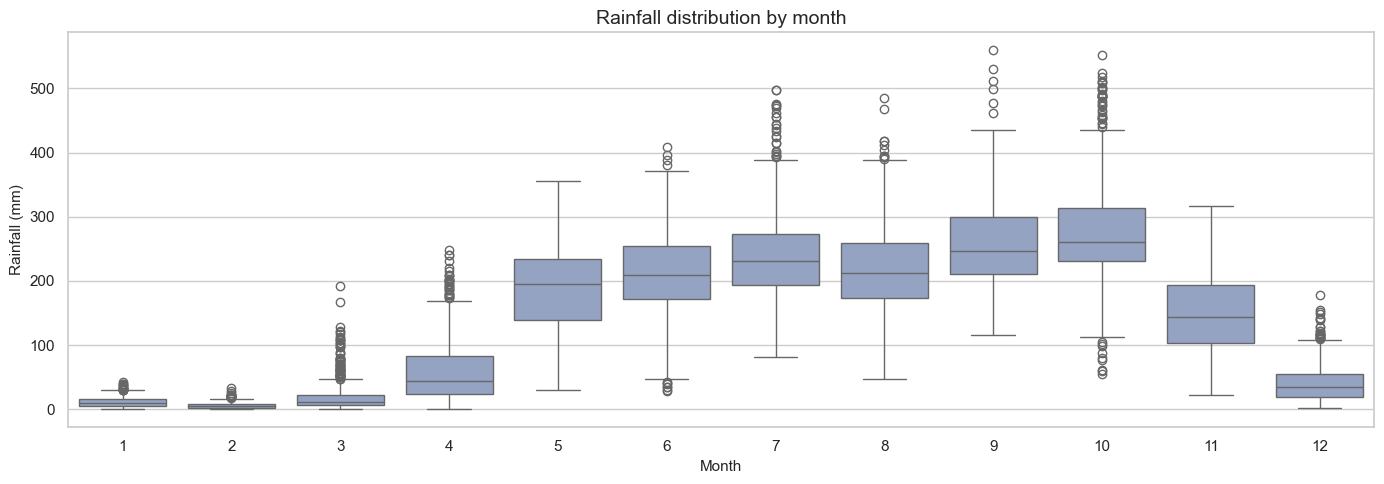

Top 10 highest records - Rainfall (rainfall_mm)


,province_name,year,month,date,rainfall_mm
2144,Ca Mau,2024,9,2024-09-01,559.464
2097,Ca Mau,2020,10,2020-10-01,552.139
2096,Ca Mau,2020,9,2020-09-01,530.071
6297,Tra Vinh,2010,10,2010-10-01,523.623
1857,Ca Mau,2000,10,2000-10-01,518.452
777,Bac Lieu,2000,10,2000-10-01,512.363
2000,Ca Mau,2012,9,2012-09-01,512.290
237,An Giang,2000,10,2000-10-01,510.134
1509,Ben Tre,2016,10,2016-10-01,507.839
6717,Vinh Long,2000,10,2000-10-01,502.745


Top 10 lowest records - Rainfall (rainfall_mm)


,province_name,year,month,date,rainfall_mm
6902,Vinh Long,2016,3,2016-03-01,0.000
6997,Vinh Long,2024,2,2024-02-01,0.000
3097,Dong Thap,2014,2,2014-02-01,0.000
2413,Can Tho city,2002,2,2002-02-01,0.000
6937,Vinh Long,2019,2,2019-02-01,0.000
3157,Dong Thap,2019,2,2019-02-01,0.000
2461,Can Tho city,2006,2,2006-02-01,0.000
1969,Ca Mau,2010,2,2010-02-01,0.000
1500,Ben Tre,2016,1,2016-01-01,0.000
2449,Can Tho city,2005,2,2005-02-01,0.000


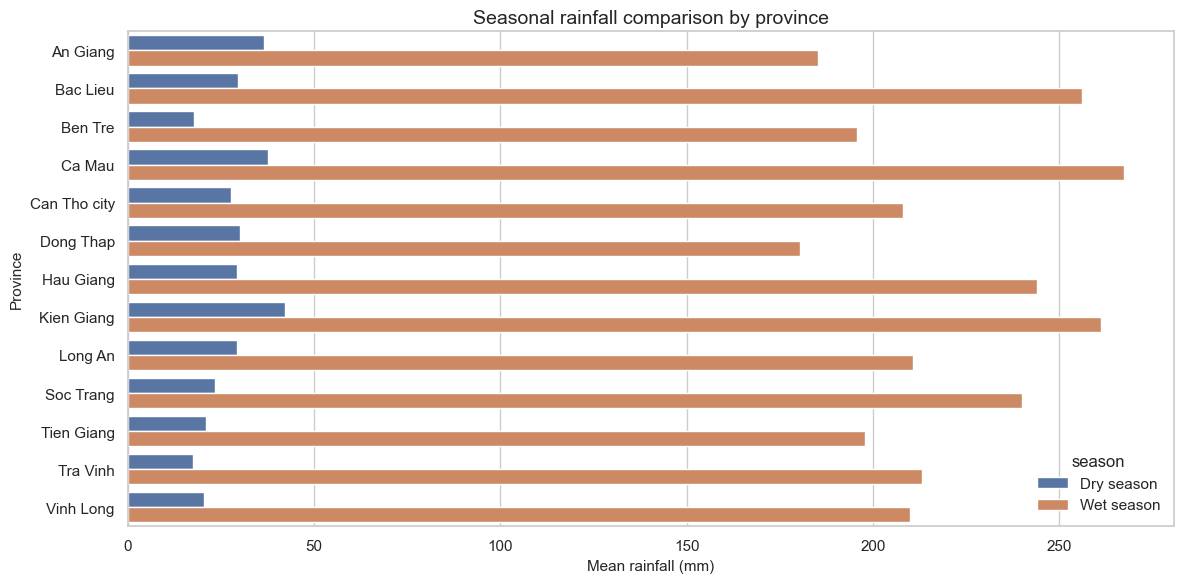

Rainfall outlier interpretation: values above the IQR bound are dominated by heavy-rain months and should be treated as potential extreme events rather than automatic errors.


In [18]:
display_section("Rainfall EDA", "Monthly province-level rainfall from 1981-2025")
rainfall_df = rainfall_df.sort_values(["province_name", "date"]).reset_index(drop=True)
rainfall_df["season"] = np.where(rainfall_df["month"].isin([5, 6, 7, 8, 9, 10, 11]), "Wet season", "Dry season")

rainfall_missing = missing_value_report(rainfall_df, "rainfall")
rainfall_duplicates = duplicate_key_report(rainfall_df, "rainfall", ["province_name", "year", "month"])
rainfall_numeric = numeric_summary(rainfall_df, "rainfall", ["rainfall_mm"])
rainfall_outliers = iqr_outlier_report(rainfall_df, "rainfall", ["rainfall_mm"])

rainfall_quality = pd.DataFrame({
    "check": [
        "invalid month rows",
        "negative rainfall rows",
        "rainfall > 500 mm rows",
        "rainfall > IQR upper bound rows",
    ],
    "value": [
        int(((rainfall_df["month"] < 1) | (rainfall_df["month"] > 12)).sum()),
        int((rainfall_df["rainfall_mm"] < 0).sum()),
        int((rainfall_df["rainfall_mm"] > 500).sum()),
        int((rainfall_df["rainfall_mm"] > float(rainfall_outliers.loc[0, "upper_bound"])).sum()),
    ],
})

display(rainfall_missing)
display(rainfall_duplicates)
display(rainfall_quality)
display(rainfall_numeric)
display(rainfall_outliers)

rainfall_min_year, rainfall_max_year = year_bounds(rainfall_df)
rainfall_min_date, rainfall_max_date = date_bounds(rainfall_df)
rainfall_province_counts = rainfall_df.groupby("province_name", as_index=False).size().rename(columns={"size": "record_count"}).sort_values("record_count", ascending=False)
rainfall_complete_grid = pd.MultiIndex.from_product(
    [sorted(rainfall_df["province_name"].unique()), range(int(rainfall_min_year), int(rainfall_max_year) + 1), range(1, 13)],
    names=["province_name", "year", "month"],
)
rainfall_actual_grid = pd.MultiIndex.from_frame(rainfall_df[["province_name", "year", "month"]].drop_duplicates())
rainfall_missing_combinations = rainfall_complete_grid.difference(rainfall_actual_grid)
rainfall_missing_combinations_df = rainfall_missing_combinations.to_frame(index=False)
rainfall_province_year_month = rainfall_df.groupby(["province_name", "year"], as_index=False).agg(month_count=("month", "nunique"), record_count=("rainfall_mm", "size"))
rainfall_monthly_climatology = rainfall_df.groupby("month", as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"), median_rainfall_mm=("rainfall_mm", "median"), p25_rainfall_mm=("rainfall_mm", lambda s: s.quantile(0.25)), p75_rainfall_mm=("rainfall_mm", lambda s: s.quantile(0.75)))
rainfall_annual_by_province = rainfall_df.groupby(["province_name", "year"], as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"), median_rainfall_mm=("rainfall_mm", "median"), min_rainfall_mm=("rainfall_mm", "min"), max_rainfall_mm=("rainfall_mm", "max"), record_count=("rainfall_mm", "size"))
rainfall_monthly_by_province = rainfall_df.groupby(["province_name", "month"], as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"), median_rainfall_mm=("rainfall_mm", "median"), record_count=("rainfall_mm", "size"))
rainfall_by_province = rainfall_df.groupby("province_name", as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"), median_rainfall_mm=("rainfall_mm", "median"), max_rainfall_mm=("rainfall_mm", "max"), min_rainfall_mm=("rainfall_mm", "min"), record_count=("rainfall_mm", "size")).sort_values("mean_rainfall_mm", ascending=False)
rainfall_by_year = rainfall_df.groupby("year", as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"))
rainfall_by_month = rainfall_monthly_climatology.sort_values("month")
rainfall_seasonal = rainfall_df.groupby(["province_name", "season"], as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"))
rainfall_seasonal_pivot = rainfall_seasonal.pivot(index="province_name", columns="season", values="mean_rainfall_mm").reset_index()

print(f"Actual min year: {rainfall_min_year}")
print(f"Actual max year: {rainfall_max_year}")
print(f"Actual min date: {rainfall_min_date}")
print(f"Actual max date: {rainfall_max_date}")
print(f"Number of provinces: {rainfall_df['province_name'].nunique()}")
display(rainfall_province_counts)
display(rainfall_province_year_month.sort_values(["month_count", "province_name"]).head(20))
display(rainfall_missing_combinations_df.head(20))

save_table(rainfall_monthly_climatology, "rainfall_monthly_climatology.csv")
save_table(rainfall_annual_by_province, "rainfall_annual_by_province.csv")
save_table(rainfall_province_counts, "rainfall_records_per_province.csv")
save_table(rainfall_province_year_month, "rainfall_completeness_by_province_year.csv")
save_table(rainfall_by_province, "rainfall_ranked_by_province.csv")
save_table(rainfall_by_year, "rainfall_annual_by_year.csv")
save_table(rainfall_seasonal, "rainfall_seasonal_by_province.csv")

fig = plot_hist_and_box(rainfall_df, "rainfall_mm", "Rainfall")
save_figure(fig, "rainfall_hist_box.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(data=rainfall_by_month, x="month", y="mean_rainfall_mm", ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Average rainfall by month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Mean rainfall (mm)")

sns.lineplot(data=rainfall_by_year, x="year", y="mean_rainfall_mm", ax=axes[0, 1], color="#dd8452")
axes[0, 1].set_title("Average rainfall by year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Mean rainfall (mm)")

sns.barplot(data=rainfall_by_province, y="province_name", x="mean_rainfall_mm", ax=axes[1, 0], color="#55a868")
axes[1, 0].set_title("Average rainfall by province")
axes[1, 0].set_xlabel("Mean rainfall (mm)")
axes[1, 0].set_ylabel("Province")

sns.lineplot(data=rainfall_df.groupby("date", as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean")), x="date", y="mean_rainfall_mm", ax=axes[1, 1], color="#c44e52")
axes[1, 1].set_title("Monthly average rainfall time series")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Mean rainfall (mm)")

plt.tight_layout()
save_figure(fig, "rainfall_core_trends.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
rainfall_year_pivot = rainfall_annual_by_province.pivot(index="province_name", columns="year", values="mean_rainfall_mm")
rainfall_month_pivot = rainfall_monthly_by_province.pivot(index="province_name", columns="month", values="mean_rainfall_mm")
sns.heatmap(rainfall_year_pivot, cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Mean rainfall (mm)"})
axes[0].set_title("Province vs year: annual mean rainfall")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Province")
sns.heatmap(rainfall_month_pivot, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Mean rainfall (mm)"})
axes[1].set_title("Province vs month: monthly mean rainfall")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Province")
plt.tight_layout()
save_figure(fig, "rainfall_heatmaps.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=rainfall_df, x="month", y="rainfall_mm", ax=ax, color="#8da0cb")
ax.set_title("Rainfall distribution by month")
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
save_figure(fig, "rainfall_box_by_month.png")
plt.show()
plt.close(fig)

top_rainfall, bottom_rainfall = plot_top_bottom_records(rainfall_df, "rainfall_mm", ["province_name", "year", "month", "date"], "Rainfall")
save_table(top_rainfall, "rainfall_top_10_wettest.csv")
save_table(bottom_rainfall, "rainfall_top_10_driest.csv")

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=rainfall_seasonal, y="province_name", x="mean_rainfall_mm", hue="season", ax=ax)
ax.set_title("Seasonal rainfall comparison by province")
ax.set_xlabel("Mean rainfall (mm)")
ax.set_ylabel("Province")
plt.tight_layout()
save_figure(fig, "rainfall_seasonal_comparison.png")
plt.show()
plt.close(fig)

print("Rainfall outlier interpretation: values above the IQR bound are dominated by heavy-rain months and should be treated as potential extreme events rather than automatic errors.")

In [19]:
# ### Rainfall Interpretation

# The rainfall table is complete at the province-month level in the observed raw file: there are no missing province-year-month combinations and no duplicate keys. Rainfall values look plausible for a Mekong Delta climate dataset, with most months concentrated in the wet season and a long dry-season tail close to zero.

# The strongest monthly pattern is the expected wet-season buildup from roughly May through October, with the highest average rainfall around the late wet season. Provinces such as Ca Mau, Kien Giang, Bac Lieu, and Hau Giang tend to have the highest average rainfall, while the dry-season months remain low across all provinces.

# A small number of extreme high rainfall observations appear above the IQR threshold. These are more consistent with intense storm or flood-season events than obvious data errors, so they should be reviewed as potential extremes rather than removed automatically.

In [20]:
## 2. Cropland EDA

# This section reviews cropland as a static 2021 province-level exposure layer. The goal is to validate the crop share metrics and identify how they should be used later as contextual features.


Cropland EDA
Province-level cropland exposure for 2021
Cropland is a static layer: 1 year present
One row per province: 1


,dataset,column,dtype,missing_count,missing_percentage,unique_count
0,cropland,province_name,string,0,0.000,13
1,cropland,year,Int64,0,0.000,1
2,cropland,province_area_km2,float64,0,0.000,13
3,cropland,cropland_area_km2,float64,0,0.000,13
4,cropland,cropland_pct,float64,0,0.000,13


,dataset,key_columns,total_rows,duplicate_full_rows,duplicate_key_rows,duplicate_key_percentage
0,cropland,province_name + year,13,0,0,0.000


,check,value
0,unique years present,[2021]
1,duplicate province-year rows,0
2,negative province area rows,0
3,negative cropland area rows,0
4,cropland pct < 0 rows,0
5,cropland pct > 100 rows,0
6,cropland area > province area rows,0


,dataset,column,count,mean,median,std,min,p05,p25,p75,p95,max
0,cropland,province_area_km2,13,"3,109.212","2,610.874","1,480.690","1,398.217","1,480.078","2,254.440","3,540.966","5,629.231","6,294.256"
1,cropland,cropland_area_km2,13,"1,501.872","1,080.987","1,000.410",213.475,454.997,869.755,"2,180.707","3,104.638","3,560.913"
2,cropland,cropland_pct,13,47.381,54.500,18.422,9.309,16.230,40.010,62.205,67.583,72.558


,dataset,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,cropland,province_area_km2,"2,254.440","3,540.966","1,286.526",324.651,"5,470.755",1,7.692
1,cropland,cropland_area_km2,869.755,"2,180.707","1,310.953","-1,096.675","4,147.136",0,0.000
2,cropland,cropland_pct,40.010,62.205,22.194,6.719,95.496,0,0.000


,province_name,year,province_area_km2,cropland_area_km2,cropland_pct
0,An Giang,2021,"3,540.966","2,569.247",72.558
1,Dong Thap,2021,"3,393.241","2,180.707",64.266
2,Long An,2021,"4,493.542","2,800.454",62.322
3,Can Tho city,2021,"1,398.217",869.755,62.205
4,Kien Giang,2021,"6,294.256","3,560.913",56.574
5,Soc Trang,2021,"3,348.847","1,842.158",55.009
6,Hau Giang,2021,"1,678.422",914.736,54.500
7,Bac Lieu,2021,"2,610.874","1,223.236",46.852
8,Vinh Long,2021,"1,534.652",616.011,40.140
9,Tra Vinh,2021,"2,254.440",902.010,40.010


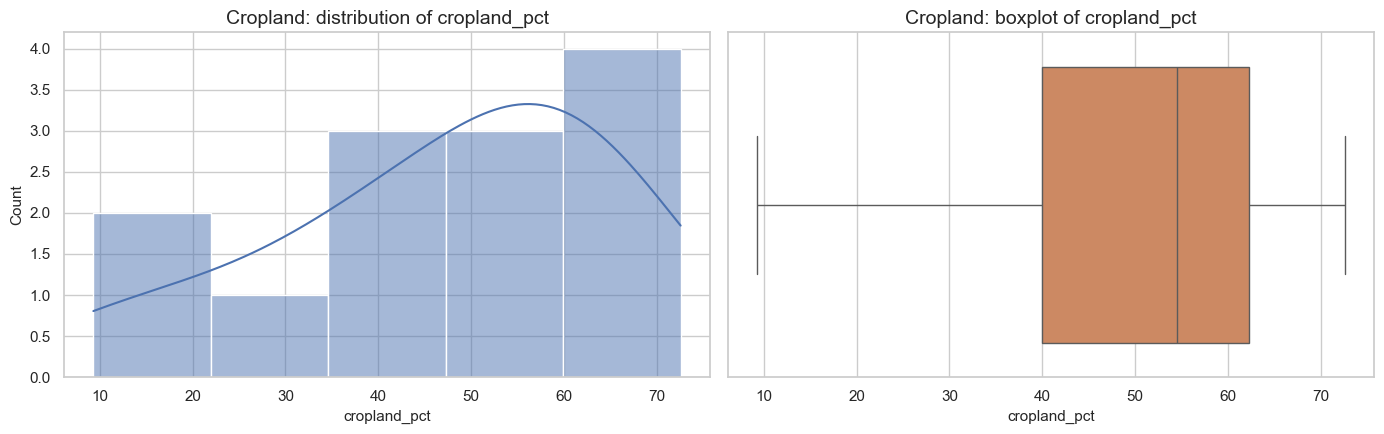

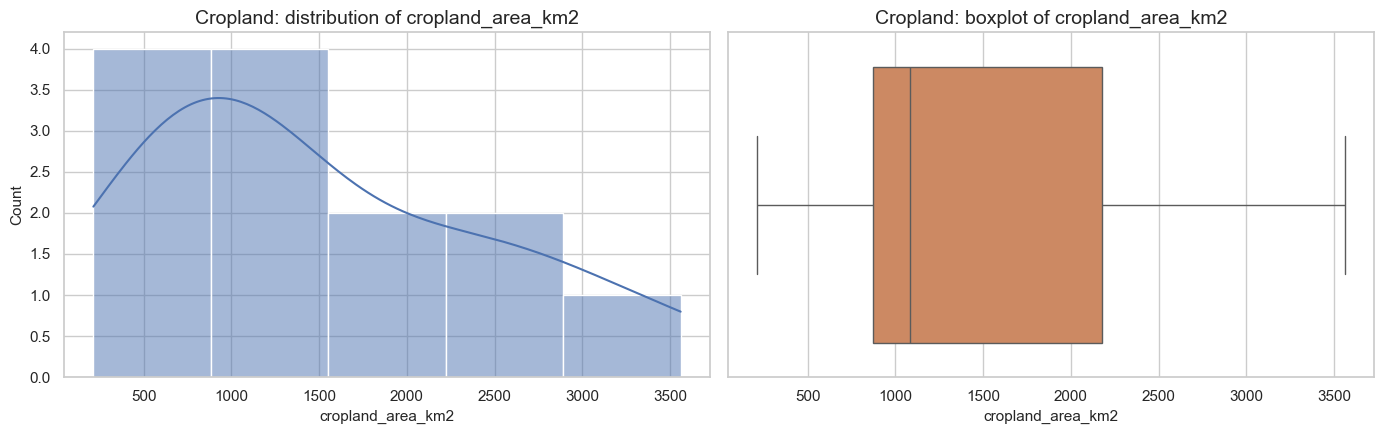

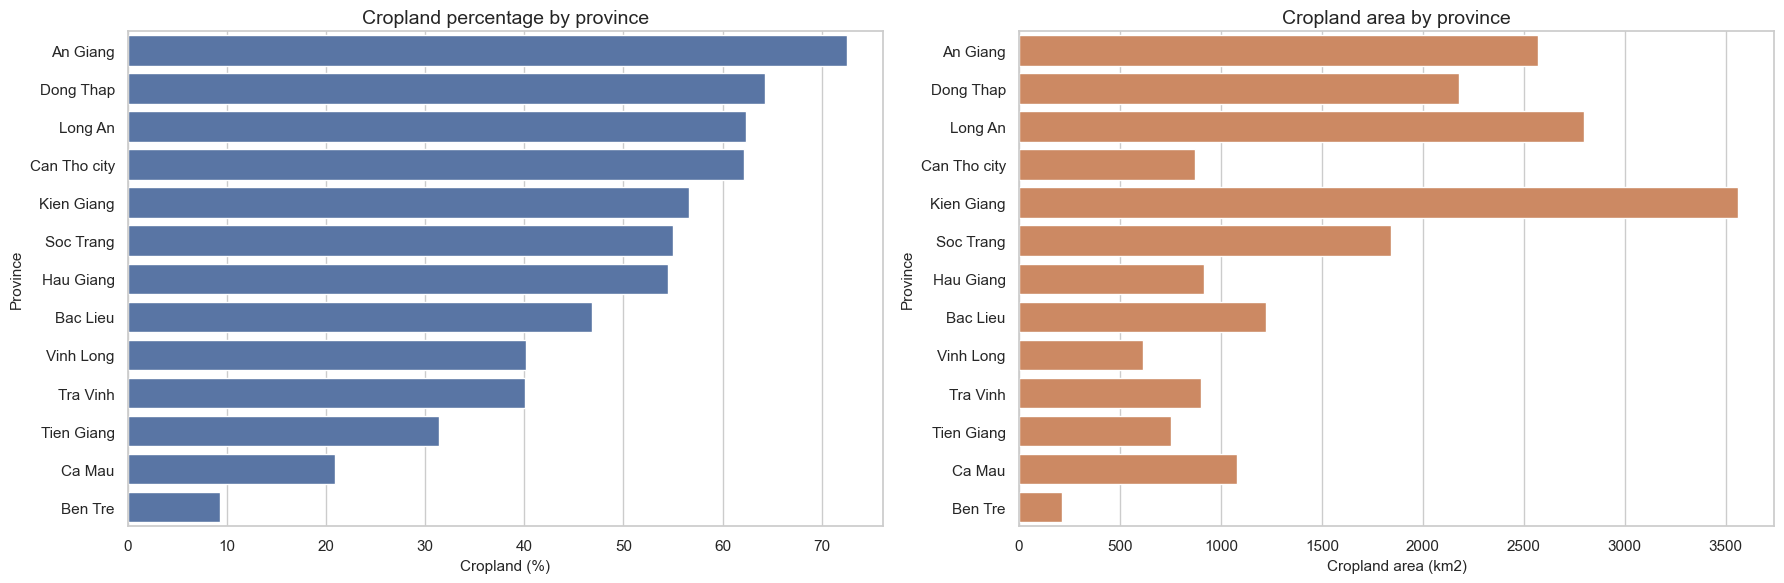

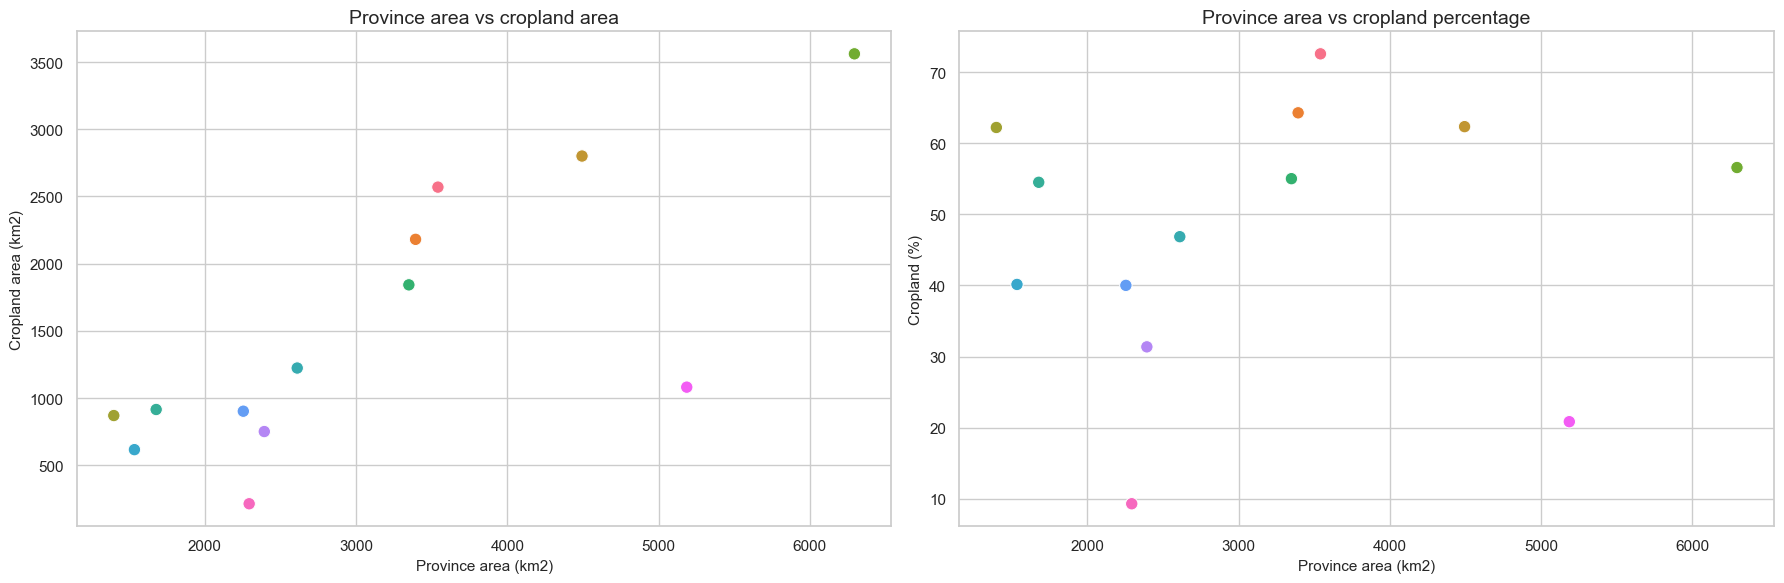

Cropland values are valid if the share remains within 0-100 and area does not exceed province area.


In [21]:
display_section("Cropland EDA", "Province-level cropland exposure for 2021")
cropland_df = cropland_df.sort_values("cropland_pct", ascending=False).reset_index(drop=True)

cropland_missing = missing_value_report(cropland_df, "cropland")
cropland_duplicates = duplicate_key_report(cropland_df, "cropland", ["province_name", "year"])
cropland_numeric = numeric_summary(cropland_df, "cropland", ["province_area_km2", "cropland_area_km2", "cropland_pct"])
cropland_outliers = iqr_outlier_report(cropland_df, "cropland", ["province_area_km2", "cropland_area_km2", "cropland_pct"])

cropland_quality = pd.DataFrame({
    "check": [
        "unique years present",
        "duplicate province-year rows",
        "negative province area rows",
        "negative cropland area rows",
        "cropland pct < 0 rows",
        "cropland pct > 100 rows",
        "cropland area > province area rows",
    ],
    "value": [
        sorted(cropland_df["year"].dropna().unique().tolist()),
        int(cropland_df.duplicated(subset=["province_name", "year"]).sum()),
        int((cropland_df["province_area_km2"] < 0).sum()),
        int((cropland_df["cropland_area_km2"] < 0).sum()),
        int((cropland_df["cropland_pct"] < 0).sum()),
        int((cropland_df["cropland_pct"] > 100).sum()),
        int((cropland_df["cropland_area_km2"] > cropland_df["province_area_km2"]).sum()),
    ],
})

cropland_ranked = cropland_df[["province_name", "year", "province_area_km2", "cropland_area_km2", "cropland_pct"]].copy()
cropland_ranked = cropland_ranked.sort_values("cropland_pct", ascending=False).reset_index(drop=True)

print(f"Cropland is a static layer: {cropland_df['year'].nunique()} year present")
print(f"One row per province: {int(cropland_df['province_name'].nunique() == len(cropland_df))}")
display(cropland_missing)
display(cropland_duplicates)
display(cropland_quality)
display(cropland_numeric)
display(cropland_outliers)
display(cropland_ranked)

save_table(cropland_ranked, "cropland_ranked_by_province.csv")

fig = plot_hist_and_box(cropland_df, "cropland_pct", "Cropland")
save_figure(fig, "cropland_hist_box_pct.png")
plt.show()
plt.close(fig)

fig = plot_hist_and_box(cropland_df, "cropland_area_km2", "Cropland")
save_figure(fig, "cropland_hist_box_area.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=cropland_ranked, y="province_name", x="cropland_pct", ax=axes[0], color="#4c72b0")
axes[0].set_title("Cropland percentage by province")
axes[0].set_xlabel("Cropland (%)")
axes[0].set_ylabel("Province")
sns.barplot(data=cropland_ranked, y="province_name", x="cropland_area_km2", ax=axes[1], color="#dd8452")
axes[1].set_title("Cropland area by province")
axes[1].set_xlabel("Cropland area (km2)")
axes[1].set_ylabel("Province")
plt.tight_layout()
save_figure(fig, "cropland_ranked_bars.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(data=cropland_df, x="province_area_km2", y="cropland_area_km2", hue="province_name", s=80, ax=axes[0], legend=False, color="#55a868")
axes[0].set_title("Province area vs cropland area")
axes[0].set_xlabel("Province area (km2)")
axes[0].set_ylabel("Cropland area (km2)")
sns.scatterplot(data=cropland_df, x="province_area_km2", y="cropland_pct", hue="province_name", s=80, ax=axes[1], legend=False, color="#c44e52")
axes[1].set_title("Province area vs cropland percentage")
axes[1].set_xlabel("Province area (km2)")
axes[1].set_ylabel("Cropland (%)")
plt.tight_layout()
save_figure(fig, "cropland_scatter_relationships.png")
plt.show()
plt.close(fig)

print("Cropland values are valid if the share remains within 0-100 and area does not exceed province area.")

In [22]:
## 4. Population EDA

# This section reviews annual population and density as exposure context. The key check is whether the actual year coverage matches the filename and whether growth patterns look plausible across provinces.

In [23]:
# ### Cropland Interpretation

# Cropland is a static 2021 province-level exposure layer, not a time series. That means it should be carried forward later as a province attribute or fixed contextual feature, rather than treated as something that evolves month by month.

# The cropland values are internally consistent: there are no missing values, no duplicate province-year keys, no negative areas, no percentages below 0 or above 100, and cropland area never exceeds province area. The highest cropland shares are concentrated in An Giang, Dong Thap, Long An, Can Tho city, and Kien Giang.

# Because the sample is small and cross-sectional, the main modeling caution is to avoid over-interpreting cropland as a dynamic driver. It is better used as a static province descriptor alongside rainfall, water, and population.

In [24]:
cropland_total_area = cropland_df["cropland_area_km2"].sum()
cropland_distribution = cropland_df[["province_name", "cropland_area_km2", "cropland_pct"]].copy()
cropland_distribution["cropland_share_of_total_pct"] = (cropland_distribution["cropland_area_km2"] / cropland_total_area) * 100
cropland_distribution = cropland_distribution.sort_values("cropland_area_km2", ascending=False).reset_index(drop=True)

rainfall_province_mean = rainfall_df.groupby("province_name", as_index=False).agg(mean_rainfall_mm=("rainfall_mm", "mean"))
water_province_mean = water_df.groupby("province_name", as_index=False).agg(mean_water_area_pct=("water_area_pct", "mean"))

cropland_cross_dataset = cropland_distribution.merge(rainfall_province_mean, on="province_name", how="left").merge(water_province_mean, on="province_name", how="left").merge(population_by_province[["province_name", "latest_population_total", "latest_density"]], on="province_name", how="left")
cropland_cross_dataset["population_per_cropland_km2"] = cropland_cross_dataset["latest_population_total"] / cropland_cross_dataset["cropland_area_km2"]

cropland_relationships = cropland_cross_dataset[["cropland_area_km2", "cropland_pct", "mean_rainfall_mm", "mean_water_area_pct", "latest_population_total", "latest_density", "population_per_cropland_km2"]].corr(numeric_only=True)

cropland_top_bottom = cropland_distribution[["province_name", "cropland_area_km2", "cropland_pct", "cropland_share_of_total_pct"]].copy()

display(cropland_distribution)
display(cropland_top_bottom)
display(cropland_cross_dataset)
display(cropland_relationships)

save_table(cropland_distribution, "cropland_distribution_by_province.csv")
save_table(cropland_cross_dataset, "cropland_cross_dataset_summary.csv")
save_table(cropland_relationships.reset_index(), "cropland_relationships_correlation.csv")

NameError: name 'population_by_province' is not defined

### Cropland Analytical Interpretation

Cropland is unevenly distributed across provinces, with a small group of provinces carrying a disproportionate share of total cropland area. That makes cropland most useful as a ranking feature and a province descriptor, not as a balanced regional variable.

The province-level comparison suggests that cropland share is more informative than raw area alone because it normalizes for province size. The combined table also shows how cropland sits alongside rainfall, water, and population pressure, which is helpful for later feature selection.

For modeling, cropland should remain a static province attribute. The province-level cross-variable correlations are best treated as exploratory signals, not causal evidence.

In [ ]:
# ## 3. Water EDA

# This section examines monthly surface-water extent as a flood-proxy layer. The main focus is on validity, partial-year coverage at the start of the series, and whether large water values represent meaningful events.


Water EDA
Monthly surface-water extent from 1984-03 to 2021-12
Actual start date: 1984-03-01 00:00:00
Actual end date: 2021-12-01 00:00:00
Flag: the series starts in 1984-03, so 1984 is a partial year rather than a full calendar year.
Number of provinces: 13


,dataset,column,dtype,missing_count,missing_percentage,unique_count
0,water,province_name,string,0,0.000,13
1,water,year,Int64,0,0.000,38
2,water,month,Int64,0,0.000,12
3,water,date,datetime64[us],0,0.000,454
4,water,water_area_km2,float64,0,0.000,3980
5,water,province_area_km2,float64,0,0.000,13
6,water,water_area_pct,float64,0,0.000,3980


,dataset,key_columns,total_rows,duplicate_full_rows,duplicate_key_rows,duplicate_key_percentage
0,water,province_name + year + month,5902,0,0,0.000


,check,value
0,invalid month rows,0
1,negative water area rows,0
2,water_area_pct < 0 rows,0
3,water_area_pct > 100 rows,0


,dataset,column,count,mean,median,std,min,p05,p25,p75,p95,max
0,water,water_area_km2,5902,194.756,56.649,343.393,0.000,0.000,0.000,232.640,937.535,"2,373.767"
1,water,water_area_pct,5902,6.039,2.128,9.615,0.000,0.000,0.000,8.128,25.810,67.604


,dataset,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,water,water_area_km2,0.000,232.640,232.640,-348.960,581.600,569,9.641
1,water,water_area_pct,0.000,8.128,8.128,-12.191,20.319,444,7.523


,province_name,record_count
0,An Giang,454
1,Bac Lieu,454
2,Ben Tre,454
3,Ca Mau,454
4,Can Tho city,454
5,Dong Thap,454
6,Hau Giang,454
7,Kien Giang,454
8,Long An,454
9,Soc Trang,454


,province_name,year,month_count,record_count
0,An Giang,1984,10,10
38,Bac Lieu,1984,10,10
76,Ben Tre,1984,10,10
114,Ca Mau,1984,10,10
152,Can Tho city,1984,10,10
190,Dong Thap,1984,10,10
228,Hau Giang,1984,10,10
266,Kien Giang,1984,10,10
304,Long An,1984,10,10
342,Soc Trang,1984,10,10


,province_name,year,month
0,An Giang,1984,1
1,An Giang,1984,2
2,Bac Lieu,1984,1
3,Bac Lieu,1984,2
4,Ben Tre,1984,1
5,Ben Tre,1984,2
6,Ca Mau,1984,1
7,Ca Mau,1984,2
8,Can Tho city,1984,1
9,Can Tho city,1984,2


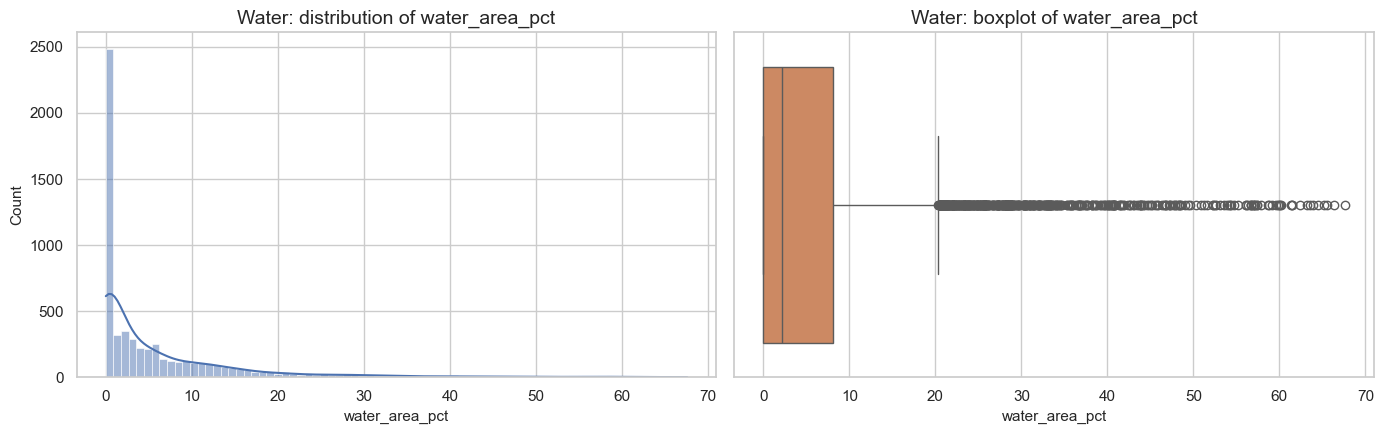

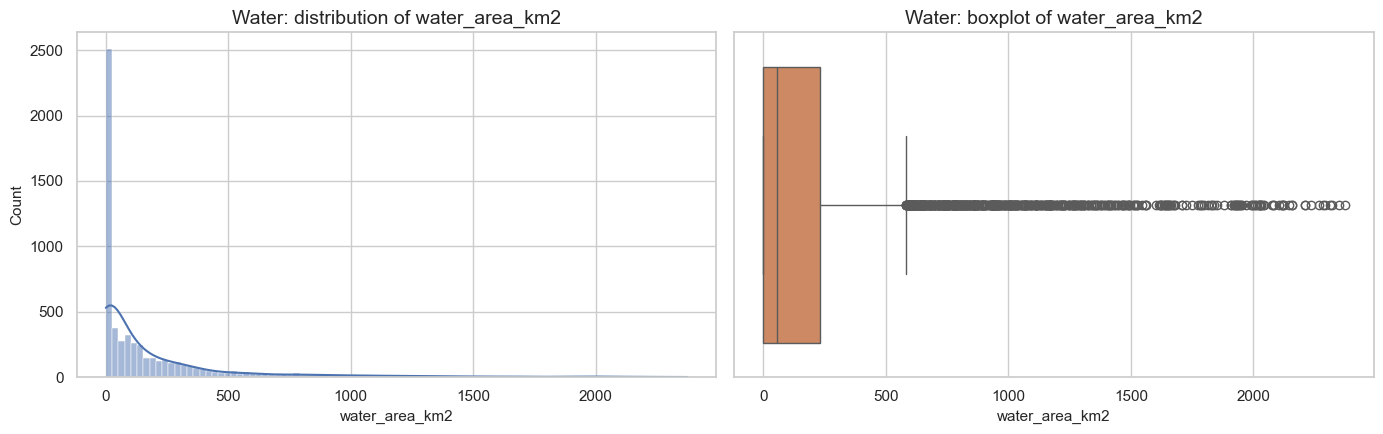

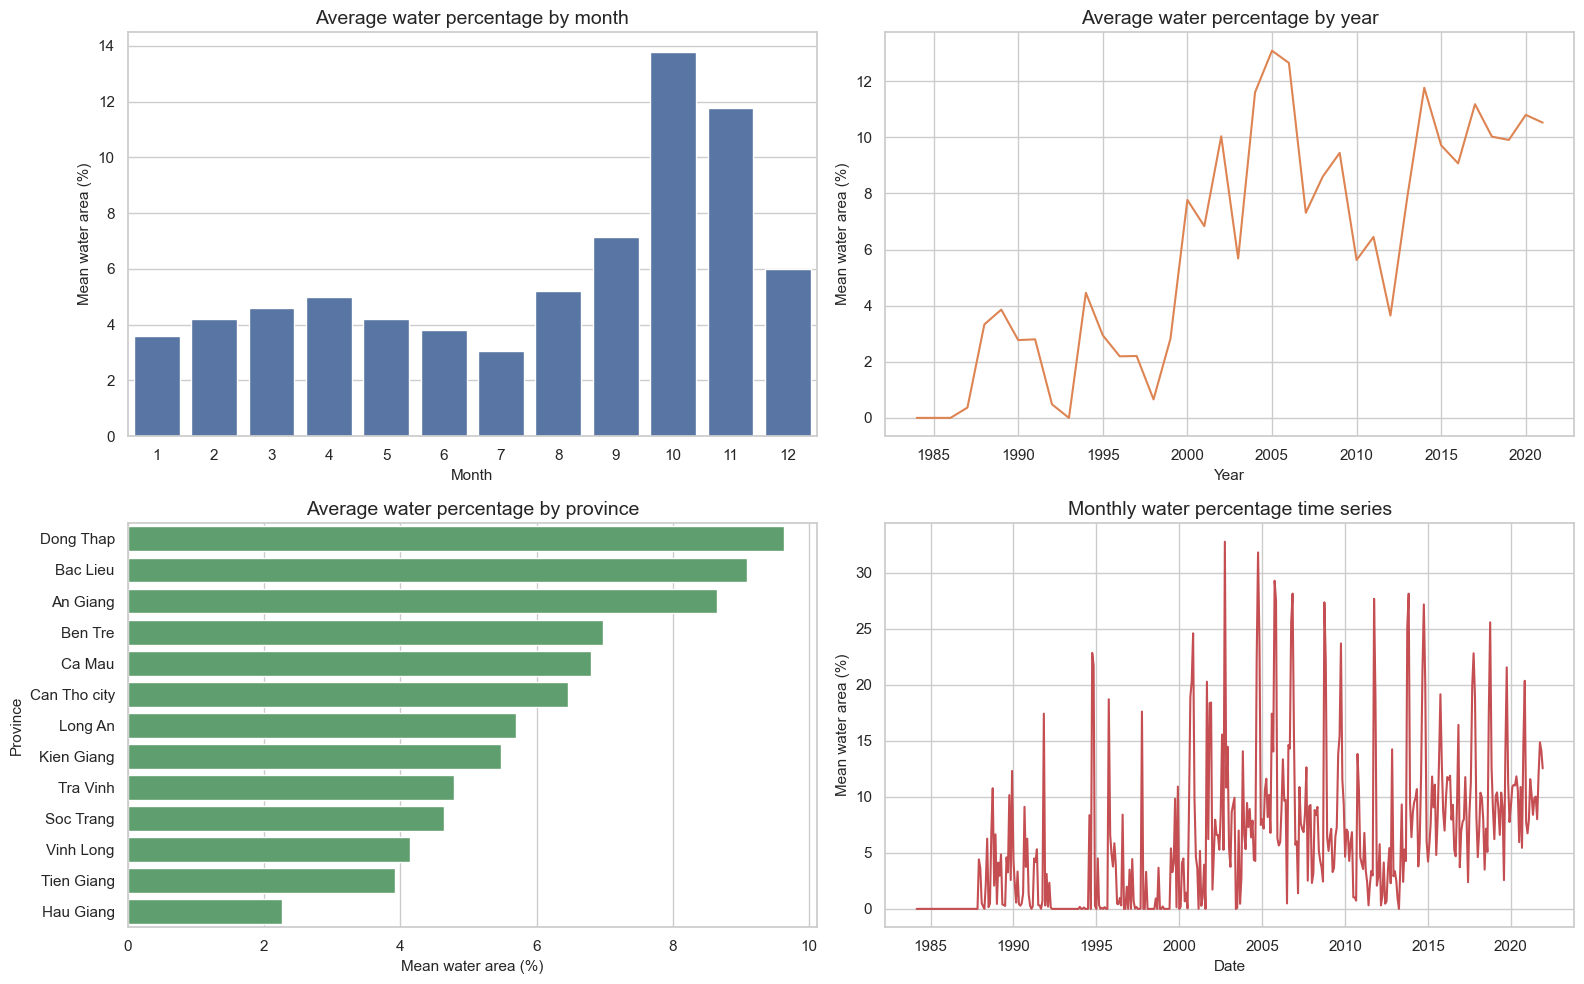

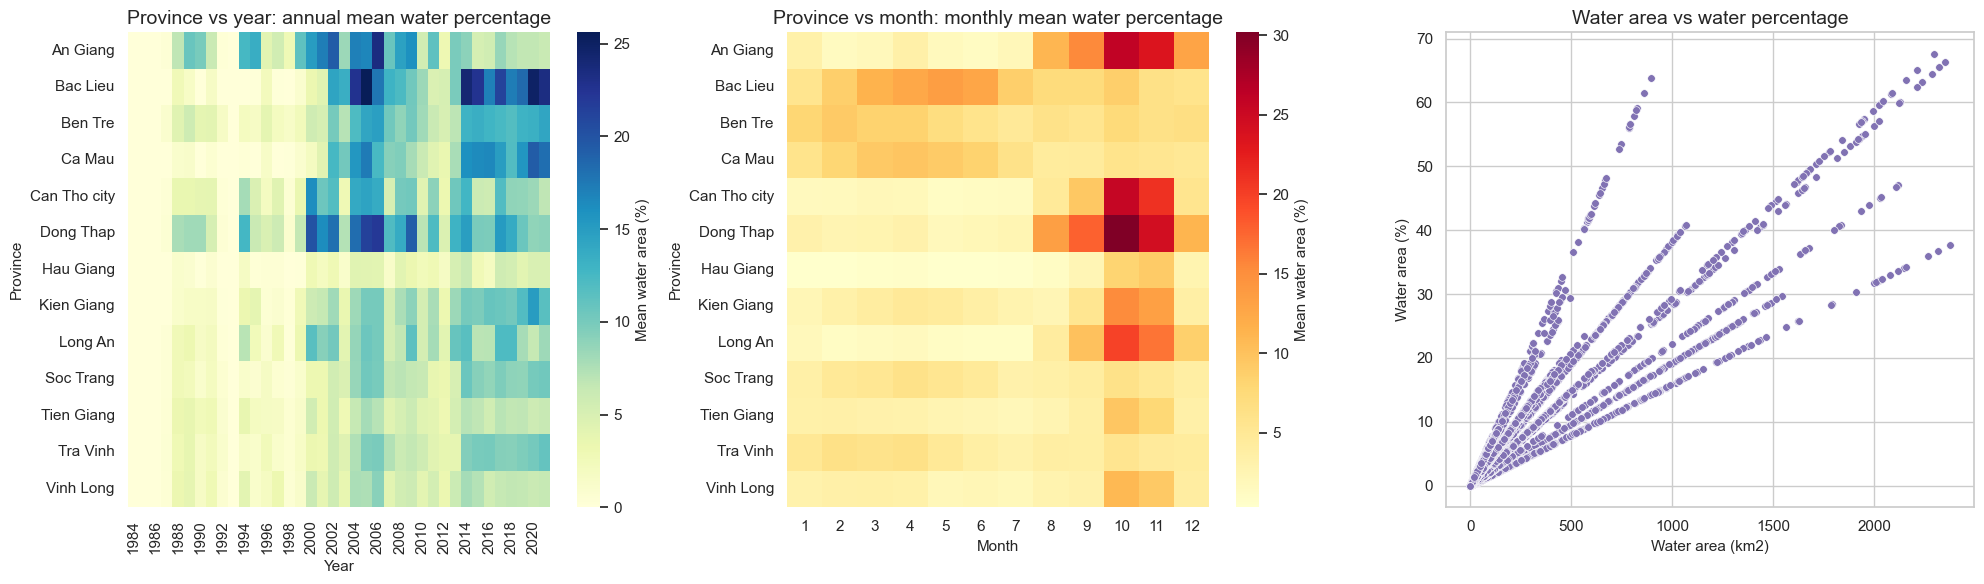

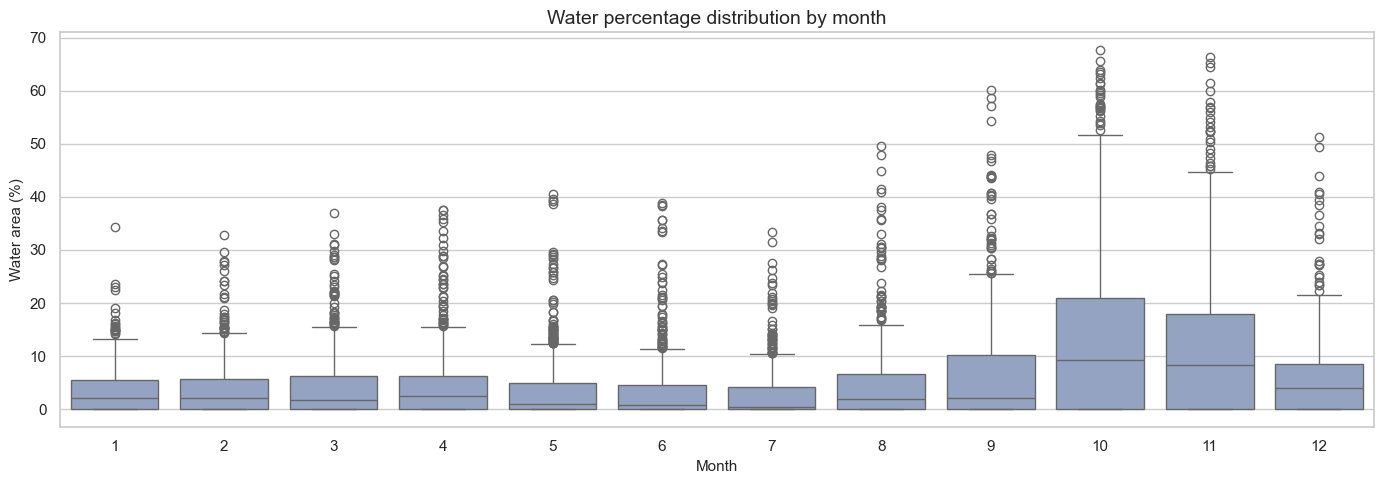

Top 10 highest records - Water (water_area_pct)


,province_name,year,month,date,water_area_pct
2493,Dong Thap,2002,10,2002-10-01,67.604
272,An Giang,2006,11,2006-11-01,66.297
223,An Giang,2002,10,2002-10-01,65.543
2470,Dong Thap,2000,11,2000-11-01,65.127
128,An Giang,1994,11,1994-11-01,64.520
2039,Can Tho city,2002,10,2002-10-01,63.872
2517,Dong Thap,2004,10,2004-10-01,63.555
139,An Giang,1995,10,1995-10-01,63.173
271,An Giang,2006,10,2006-10-01,62.400
2063,Can Tho city,2004,10,2004-10-01,61.468


Top 10 lowest records - Water (water_area_pct)


,province_name,year,month,date,water_area_pct
29,An Giang,1986,8,1986-08-01,0.000
5796,Vinh Long,2013,3,2013-03-01,0.000
5791,Vinh Long,2012,10,2012-10-01,0.000
44,An Giang,1987,11,1987-11-01,0.000
43,An Giang,1987,10,1987-10-01,0.000
42,An Giang,1987,9,1987-09-01,0.000
41,An Giang,1987,8,1987-08-01,0.000
40,An Giang,1987,7,1987-07-01,0.000
39,An Giang,1987,6,1987-06-01,0.000
38,An Giang,1987,5,1987-05-01,0.000


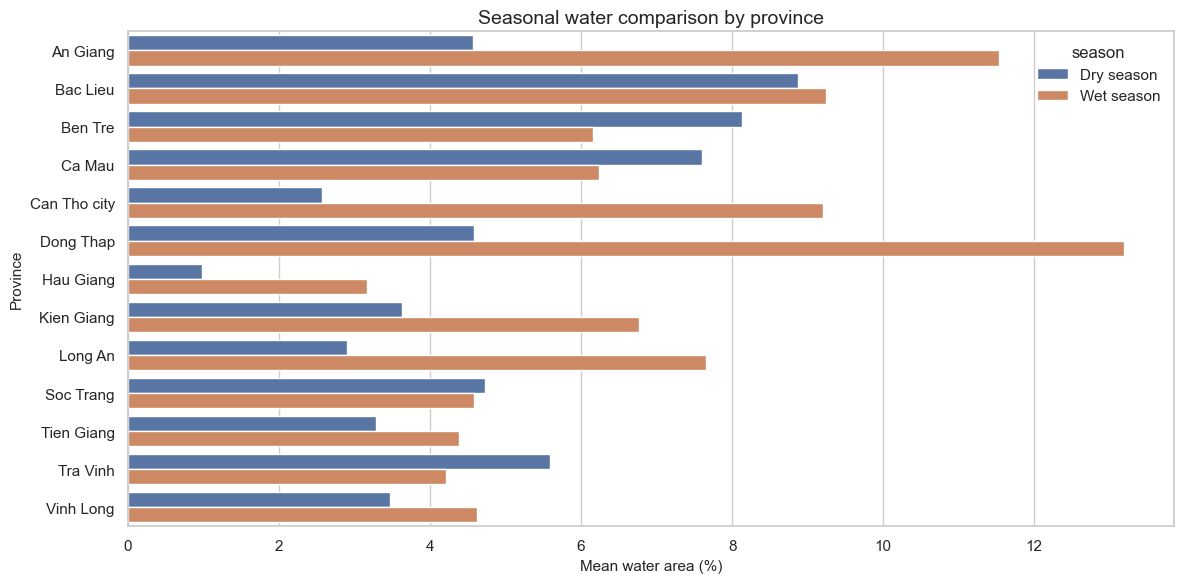

Water outlier interpretation: extreme values are likely flood or inundation proxies when they cluster in wet-season months.


In [ ]:
display_section("Water EDA", "Monthly surface-water extent from 1984-03 to 2021-12")
water_df = water_df.sort_values(["province_name", "date"]).reset_index(drop=True)

water_missing = missing_value_report(water_df, "water")
water_duplicates = duplicate_key_report(water_df, "water", ["province_name", "year", "month"])
water_numeric = numeric_summary(water_df, "water", ["water_area_km2", "water_area_pct"])
water_outliers = iqr_outlier_report(water_df, "water", ["water_area_km2", "water_area_pct"])

water_quality = pd.DataFrame({
    "check": [
        "invalid month rows",
        "negative water area rows",
        "water_area_pct < 0 rows",
        "water_area_pct > 100 rows",
    ],
    "value": [
        int(((water_df["month"] < 1) | (water_df["month"] > 12)).sum()),
        int((water_df["water_area_km2"] < 0).sum()),
        int((water_df["water_area_pct"] < 0).sum()),
        int((water_df["water_area_pct"] > 100).sum()),
    ],
})

water_min_year, water_max_year = year_bounds(water_df)
water_min_date, water_max_date = date_bounds(water_df)
water_province_counts = water_df.groupby("province_name", as_index=False).size().rename(columns={"size": "record_count"}).sort_values("record_count", ascending=False)
water_province_year_month = water_df.groupby(["province_name", "year"], as_index=False).agg(month_count=("month", "nunique"), record_count=("water_area_pct", "size"))
water_annual_by_province = water_df.groupby(["province_name", "year"], as_index=False).agg(mean_water_area_km2=("water_area_km2", "mean"), mean_water_area_pct=("water_area_pct", "mean"), median_water_area_pct=("water_area_pct", "median"), record_count=("water_area_pct", "size"))
water_monthly_climatology = water_df.groupby("month", as_index=False).agg(mean_water_area_km2=("water_area_km2", "mean"), mean_water_area_pct=("water_area_pct", "mean"))
water_by_year = water_df.groupby("year", as_index=False).agg(mean_water_area_pct=("water_area_pct", "mean"))
water_by_province = water_df.groupby("province_name", as_index=False).agg(mean_water_area_km2=("water_area_km2", "mean"), mean_water_area_pct=("water_area_pct", "mean"), max_water_area_pct=("water_area_pct", "max"), record_count=("water_area_pct", "size")).sort_values("mean_water_area_pct", ascending=False)
water_monthly_by_province = water_df.groupby(["province_name", "month"], as_index=False).agg(mean_water_area_pct=("water_area_pct", "mean"))
water_seasonal = pd.DataFrame({
    "season": np.where(water_df["month"].isin([5, 6, 7, 8, 9, 10, 11]), "Wet season", "Dry season"),
    "province_name": water_df["province_name"],
    "water_area_pct": water_df["water_area_pct"],
}).groupby(["province_name", "season"], as_index=False).agg(mean_water_area_pct=("water_area_pct", "mean"))

print(f"Actual start date: {water_min_date}")
print(f"Actual end date: {water_max_date}")
if water_min_date is not None and (water_min_date.year, water_min_date.month) == (1984, 3):
    print("Flag: the series starts in 1984-03, so 1984 is a partial year rather than a full calendar year.")
print(f"Number of provinces: {water_df['province_name'].nunique()}")

display(water_missing)
display(water_duplicates)
display(water_quality)
display(water_numeric)
display(water_outliers)
display(water_province_counts)
display(water_province_year_month.sort_values(["month_count", "province_name"]).head(20))

full_calendar_grid = pd.MultiIndex.from_product(
    [sorted(water_df["province_name"].unique()), range(1984, int(water_max_year) + 1), range(1, 13)],
    names=["province_name", "year", "month"],
)
water_actual_grid = pd.MultiIndex.from_frame(water_df[["province_name", "year", "month"]].drop_duplicates())
water_missing_combinations = full_calendar_grid.difference(water_actual_grid)
water_missing_combinations_df = water_missing_combinations.to_frame(index=False)
display(water_missing_combinations_df.head(20))

save_table(water_monthly_climatology, "water_monthly_climatology.csv")
save_table(water_annual_by_province, "water_annual_by_province.csv")
save_table(water_province_counts, "water_records_per_province.csv")
save_table(water_province_year_month, "water_completeness_by_province_year.csv")
save_table(water_by_province, "water_ranked_by_province.csv")
save_table(water_by_year, "water_annual_by_year.csv")
save_table(water_seasonal, "water_seasonal_by_province.csv")

fig = plot_hist_and_box(water_df, "water_area_pct", "Water")
save_figure(fig, "water_hist_box_pct.png")
plt.show()
plt.close(fig)

fig = plot_hist_and_box(water_df, "water_area_km2", "Water")
save_figure(fig, "water_hist_box_area.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.barplot(data=water_monthly_climatology, x="month", y="mean_water_area_pct", ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Average water percentage by month")
axes[0, 0].set_xlabel("Month")
axes[0, 0].set_ylabel("Mean water area (%)")

sns.lineplot(data=water_by_year, x="year", y="mean_water_area_pct", ax=axes[0, 1], color="#dd8452")
axes[0, 1].set_title("Average water percentage by year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Mean water area (%)")

sns.barplot(data=water_by_province, y="province_name", x="mean_water_area_pct", ax=axes[1, 0], color="#55a868")
axes[1, 0].set_title("Average water percentage by province")
axes[1, 0].set_xlabel("Mean water area (%)")
axes[1, 0].set_ylabel("Province")

sns.lineplot(data=water_df.groupby("date", as_index=False).agg(mean_water_area_pct=("water_area_pct", "mean")), x="date", y="mean_water_area_pct", ax=axes[1, 1], color="#c44e52")
axes[1, 1].set_title("Monthly water percentage time series")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Mean water area (%)")

plt.tight_layout()
save_figure(fig, "water_core_trends.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
water_year_pivot = water_annual_by_province.pivot(index="province_name", columns="year", values="mean_water_area_pct")
water_month_pivot = water_monthly_by_province.pivot(index="province_name", columns="month", values="mean_water_area_pct")
sns.heatmap(water_year_pivot, cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Mean water area (%)"})
axes[0].set_title("Province vs year: annual mean water percentage")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Province")
sns.heatmap(water_month_pivot, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Mean water area (%)"})
axes[1].set_title("Province vs month: monthly mean water percentage")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Province")
sns.scatterplot(data=water_df, x="water_area_km2", y="water_area_pct", ax=axes[2], color="#8172b3", s=30)
axes[2].set_title("Water area vs water percentage")
axes[2].set_xlabel("Water area (km2)")
axes[2].set_ylabel("Water area (%)")
plt.tight_layout()
save_figure(fig, "water_heatmaps_scatter.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=water_df, x="month", y="water_area_pct", ax=ax, color="#8da0cb")
ax.set_title("Water percentage distribution by month")
ax.set_xlabel("Month")
ax.set_ylabel("Water area (%)")
plt.tight_layout()
save_figure(fig, "water_box_by_month.png")
plt.show()
plt.close(fig)

top_water, bottom_water = plot_top_bottom_records(water_df, "water_area_pct", ["province_name", "year", "month", "date"], "Water")
save_table(top_water, "water_top_10_highest_pct.csv")
save_table(bottom_water, "water_top_10_lowest_pct.csv")

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=water_seasonal, y="province_name", x="mean_water_area_pct", hue="season", ax=ax)
ax.set_title("Seasonal water comparison by province")
ax.set_xlabel("Mean water area (%)")
ax.set_ylabel("Province")
plt.tight_layout()
save_figure(fig, "water_seasonal_comparison.png")
plt.show()
plt.close(fig)

print("Water outlier interpretation: extreme values are likely flood or inundation proxies when they cluster in wet-season months.")


Population EDA
Annual province-level population totals from the raw file
Actual year coverage: 2000 to 2020
Flag: the file name suggests 2000-2021, but the observed raw data ends at 2020.
Date month values: [1]
Date day values: [1]


,dataset,column,dtype,missing_count,missing_percentage,unique_count
0,population,province_name,string,0,0.000,13
1,population,year,Int64,0,0.000,21
2,population,date,datetime64[us],0,0.000,21
3,population,population_total,float64,0,0.000,273
4,population,province_area_km2,float64,0,0.000,13
5,population,population_density_per_km2,float64,0,0.000,273


,dataset,key_columns,total_rows,duplicate_full_rows,duplicate_key_rows,duplicate_key_percentage
0,population,province_name + year,273,0,0,0.000


,check,value
0,negative population rows,0
1,zero population rows,0
2,negative density rows,0
3,actual min year,2000
4,actual max year,2020
5,filename mismatch flag,True


,dataset,column,count,mean,median,std,min,p05,p25,p75,p95,max
0,population,population_total,273,"1,139,592.017","1,087,615.154","320,739.048","637,849.866","687,976.134","880,185.497","1,384,804.022","1,819,250.458","1,941,790.182"
1,population,population_density_per_km2,273,418.123,404.587,153.279,185.946,201.457,291.046,535.455,659.847,876.063


,dataset,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,population,population_total,"880,185.497","1,384,804.022","504,618.525","123,257.709","2,141,731.810",0,0.000
1,population,population_density_per_km2,291.046,535.455,244.409,-75.567,902.068,0,0.000


,province_name,record_count
0,An Giang,21
1,Bac Lieu,21
2,Ben Tre,21
3,Ca Mau,21
4,Can Tho city,21
5,Dong Thap,21
6,Hau Giang,21
7,Kien Giang,21
8,Long An,21
9,Soc Trang,21


,province_name,year,record_count
0,An Giang,2000,1
1,An Giang,2001,1
2,An Giang,2002,1
3,An Giang,2003,1
4,An Giang,2004,1
5,An Giang,2005,1
6,An Giang,2006,1
7,An Giang,2007,1
8,An Giang,2008,1
9,An Giang,2009,1


,province_name,year


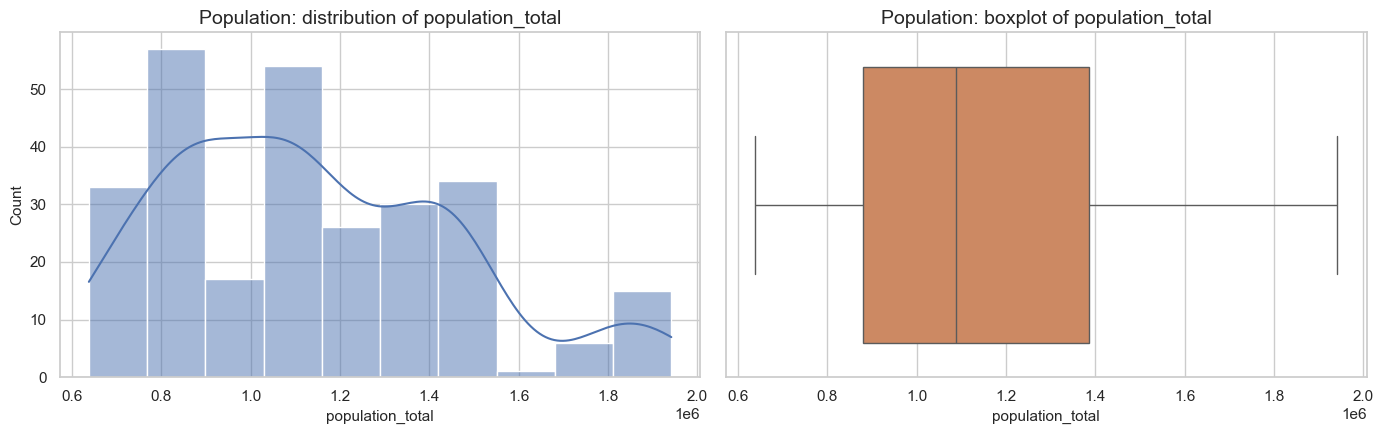

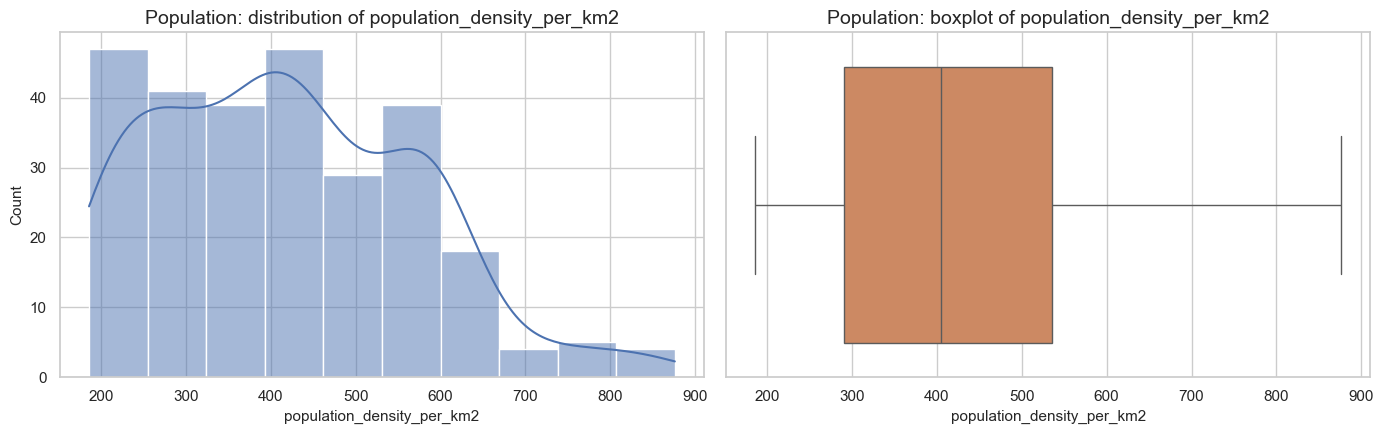

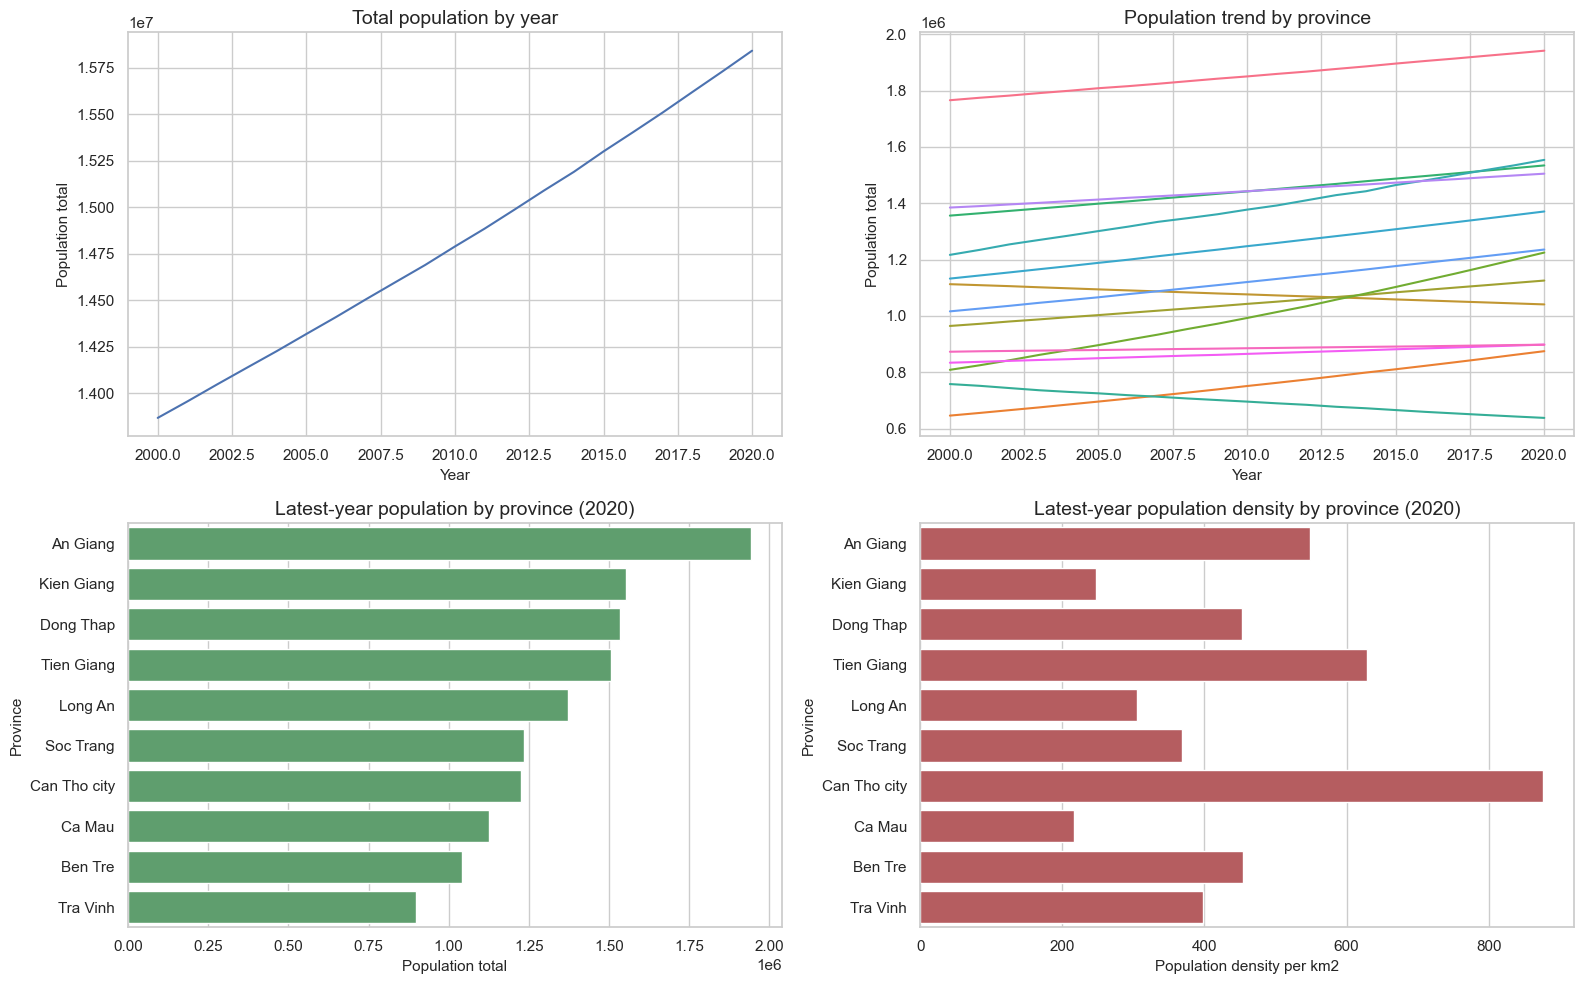

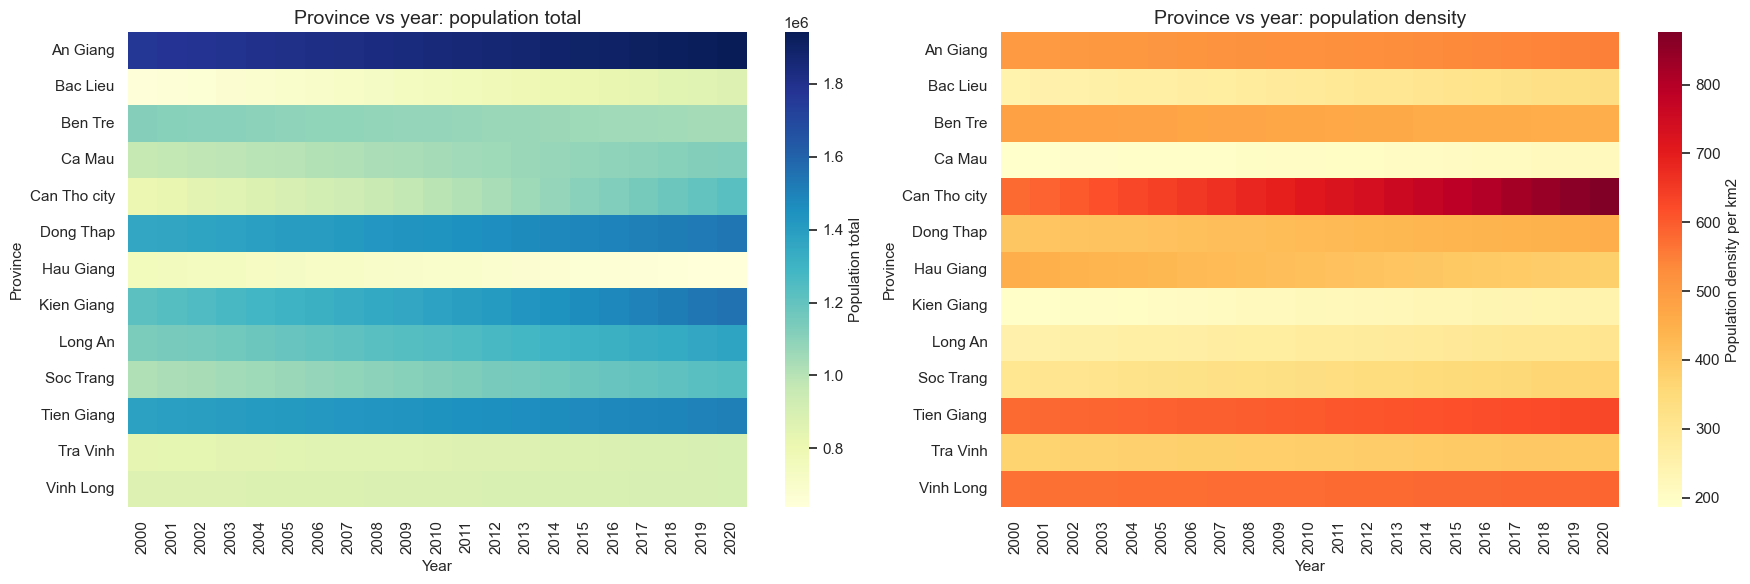

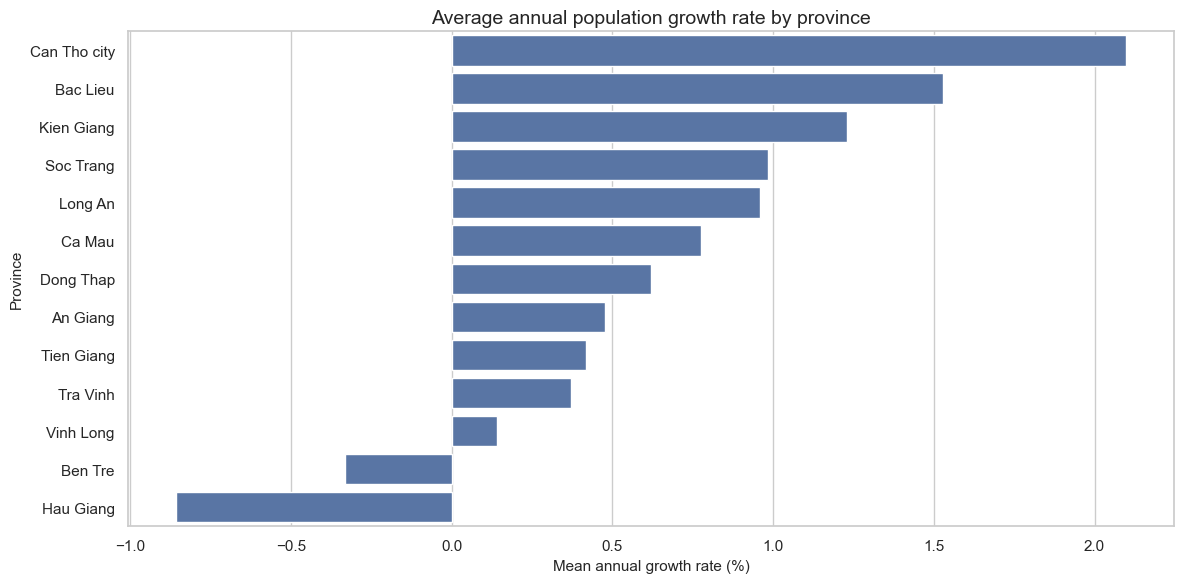

Top 10 highest records - Population (population_total)


,province_name,year,date,population_total
20,An Giang,2020,2020-01-01,"1,941,790.182"
19,An Giang,2019,2019-01-01,"1,932,442.569"
18,An Giang,2018,2018-01-01,"1,923,325.214"
17,An Giang,2017,2017-01-01,"1,913,974.321"
16,An Giang,2016,2016-01-01,"1,905,282.096"
15,An Giang,2015,2015-01-01,"1,896,028.298"
14,An Giang,2014,2014-01-01,"1,886,009.328"
13,An Giang,2013,2013-01-01,"1,876,940.459"
12,An Giang,2012,2012-01-01,"1,867,553.828"
11,An Giang,2011,2011-01-01,"1,859,312.417"


Top 10 lowest records - Population (population_total)


,province_name,year,date,population_total
146,Hau Giang,2020,2020-01-01,"637,849.866"
145,Hau Giang,2019,2019-01-01,"642,872.186"
21,Bac Lieu,2000,2000-01-01,"645,959.925"
144,Hau Giang,2018,2018-01-01,"648,192.459"
143,Hau Giang,2017,2017-01-01,"653,695.092"
22,Bac Lieu,2001,2001-01-01,"655,421.358"
142,Hau Giang,2016,2016-01-01,"659,227.149"
23,Bac Lieu,2002,2002-01-01,"665,254.772"
141,Hau Giang,2015,2015-01-01,"665,639.764"
140,Hau Giang,2014,2014-01-01,"672,036.163"


,province_name,year,previous_population_total,population_total,growth_abs,growth_rate_pct
92,Can Tho city,2013,"1,034,338.851","1,057,804.473","23,465.622",2.269
82,Can Tho city,2003,"842,384.503","861,458.412","19,073.909",2.264
97,Can Tho city,2018,"1,150,164.477","1,174,972.829","24,808.352",2.157
95,Can Tho city,2016,"1,102,725.722","1,126,506.498","23,780.777",2.157
81,Can Tho city,2002,"824,636.949","842,384.503","17,747.554",2.152
94,Can Tho city,2015,"1,079,538.419","1,102,725.722","23,187.302",2.148
87,Can Tho city,2008,"933,572.888","953,598.608","20,025.720",2.145
98,Can Tho city,2019,"1,174,972.829","1,199,978.975","25,006.146",2.128
90,Can Tho city,2011,"992,617.916","1,013,675.472","21,057.556",2.121
85,Can Tho city,2006,"896,294.964","915,299.751","19,004.788",2.120


,province_name,year,previous_population_total,population_total,growth_abs,growth_rate_pct
121,Hau Giang,2002,"751,748.885","743,813.123","-7,935.761",-1.056
122,Hau Giang,2003,"743,813.123","736,056.546","-7,756.578",-1.043
132,Hau Giang,2013,"684,314.578","677,306.804","-7,007.775",-1.024
135,Hau Giang,2016,"665,639.764","659,227.149","-6,412.615",-0.963
134,Hau Giang,2015,"672,036.163","665,639.764","-6,396.399",-0.952
125,Hau Giang,2006,"725,028.267","718,450.063","-6,578.203",-0.907
127,Hau Giang,2008,"713,034.534","706,722.465","-6,312.069",-0.885
130,Hau Giang,2011,"695,648.860","689,619.092","-6,029.768",-0.867
137,Hau Giang,2018,"653,695.092","648,192.459","-5,502.634",-0.842
136,Hau Giang,2017,"659,227.149","653,695.092","-5,532.056",-0.839


Population growth looks plausible if annual changes are moderate and consistent across years; the main issue is the filename covering 2021 while the actual raw data stops at 2020.


In [ ]:
display_section("Population EDA", "Annual province-level population totals from the raw file")
population_df = population_df.sort_values(["province_name", "year"]).reset_index(drop=True)

population_missing = missing_value_report(population_df, "population")
population_duplicates = duplicate_key_report(population_df, "population", ["province_name", "year"])
population_numeric = numeric_summary(population_df, "population", ["population_total", "population_density_per_km2"])
population_outliers = iqr_outlier_report(population_df, "population", ["population_total", "population_density_per_km2"])

population_quality = pd.DataFrame({
    "check": [
        "negative population rows",
        "zero population rows",
        "negative density rows",
        "actual min year",
        "actual max year",
        "filename mismatch flag",
    ],
    "value": [
        int((population_df["population_total"] < 0).sum()),
        int((population_df["population_total"] <= 0).sum()),
        int((population_df["population_density_per_km2"] < 0).sum()),
        int(population_df["year"].min()),
        int(population_df["year"].max()),
        bool(int(population_df["year"].max()) < 2021),
    ],
})

population_min_year, population_max_year = year_bounds(population_df)
population_province_counts = population_df.groupby("province_name", as_index=False).size().rename(columns={"size": "record_count"}).sort_values("record_count", ascending=False)
population_province_year = population_df.groupby(["province_name", "year"], as_index=False).agg(record_count=("population_total", "size"))
population_by_year = population_df.groupby("year", as_index=False).agg(total_population=("population_total", "sum"), mean_population_density_per_km2=("population_density_per_km2", "mean"))
population_by_province = population_df.groupby("province_name", as_index=False).agg(mean_population_total=("population_total", "mean"), mean_population_density_per_km2=("population_density_per_km2", "mean"), latest_population_total=("population_total", "last"), latest_density=("population_density_per_km2", "last")).sort_values("latest_population_total", ascending=False)
population_growth_df = population_df.sort_values(["province_name", "year"]).copy()
population_growth_df["previous_population_total"] = population_growth_df.groupby("province_name")["population_total"].shift(1)
population_growth_df["growth_abs"] = population_growth_df["population_total"] - population_growth_df["previous_population_total"]
population_growth_df["growth_rate_pct"] = (population_growth_df["growth_abs"] / population_growth_df["previous_population_total"]) * 100
population_growth_records = population_growth_df.dropna(subset=["previous_population_total"]).reset_index(drop=True)
population_growth_by_province = population_growth_records.groupby("province_name", as_index=False).agg(mean_growth_abs=("growth_abs", "mean"), mean_growth_rate_pct=("growth_rate_pct", "mean"), latest_growth_abs=("growth_abs", "last"), latest_growth_rate_pct=("growth_rate_pct", "last")).sort_values("mean_growth_rate_pct", ascending=False)

print(f"Actual year coverage: {population_min_year} to {population_max_year}")
if int(population_max_year) < 2021:
    print("Flag: the file name suggests 2000-2021, but the observed raw data ends at 2020.")
print(f"Date month values: {sorted(population_df['date'].dt.month.dropna().unique().tolist())}")
print(f"Date day values: {sorted(population_df['date'].dt.day.dropna().unique().tolist())}")
display(population_missing)
display(population_duplicates)
display(population_quality)
display(population_numeric)
display(population_outliers)
display(population_province_counts)
display(population_province_year.head(20))

full_population_grid = pd.MultiIndex.from_product(
    [sorted(population_df["province_name"].unique()), range(int(population_min_year), int(population_max_year) + 1)],
    names=["province_name", "year"],
)
population_actual_grid = pd.MultiIndex.from_frame(population_df[["province_name", "year"]].drop_duplicates())
population_missing_combinations = full_population_grid.difference(population_actual_grid)
population_missing_combinations_df = population_missing_combinations.to_frame(index=False)
display(population_missing_combinations_df.head(20))

save_table(population_province_counts, "population_records_per_province.csv")
save_table(population_province_year, "population_completeness_by_province_year.csv")
save_table(population_by_year, "population_by_year.csv")
save_table(population_by_province, "population_ranked_by_province.csv")
save_table(population_growth_records, "population_growth_by_province.csv")
save_table(population_growth_by_province, "population_average_growth_by_province.csv")

fig = plot_hist_and_box(population_df, "population_total", "Population")
save_figure(fig, "population_hist_box_total.png")
plt.show()
plt.close(fig)

fig = plot_hist_and_box(population_df, "population_density_per_km2", "Population")
save_figure(fig, "population_hist_box_density.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.lineplot(data=population_by_year, x="year", y="total_population", ax=axes[0, 0], color="#4c72b0")
axes[0, 0].set_title("Total population by year")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Population total")

sns.lineplot(data=population_df, x="year", y="population_total", hue="province_name", ax=axes[0, 1], legend=False)
axes[0, 1].set_title("Population trend by province")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Population total")

sns.barplot(data=population_by_province.head(10), y="province_name", x="latest_population_total", ax=axes[1, 0], color="#55a868")
axes[1, 0].set_title(f"Latest-year population by province ({int(population_max_year)})")
axes[1, 0].set_xlabel("Population total")
axes[1, 0].set_ylabel("Province")

sns.barplot(data=population_by_province.head(10), y="province_name", x="latest_density", ax=axes[1, 1], color="#c44e52")
axes[1, 1].set_title(f"Latest-year population density by province ({int(population_max_year)})")
axes[1, 1].set_xlabel("Population density per km2")
axes[1, 1].set_ylabel("Province")

plt.tight_layout()
save_figure(fig, "population_core_trends.png")
plt.show()
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pop_total_pivot = population_df.pivot(index="province_name", columns="year", values="population_total")
pop_density_pivot = population_df.pivot(index="province_name", columns="year", values="population_density_per_km2")
sns.heatmap(pop_total_pivot, cmap="YlGnBu", ax=axes[0], cbar_kws={"label": "Population total"})
axes[0].set_title("Province vs year: population total")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Province")
sns.heatmap(pop_density_pivot, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Population density per km2"})
axes[1].set_title("Province vs year: population density")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Province")
plt.tight_layout()
save_figure(fig, "population_heatmaps.png")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=population_growth_by_province, y="province_name", x="mean_growth_rate_pct", ax=ax, color="#4c72b0")
ax.set_title("Average annual population growth rate by province")
ax.set_xlabel("Mean annual growth rate (%)")
ax.set_ylabel("Province")
plt.tight_layout()
save_figure(fig, "population_growth_bar.png")
plt.show()
plt.close(fig)

highest_population, lowest_population = plot_top_bottom_records(population_df, "population_total", ["province_name", "year", "date"], "Population")
highest_growth = population_growth_records.sort_values("growth_rate_pct", ascending=False).head(10)[["province_name", "year", "previous_population_total", "population_total", "growth_abs", "growth_rate_pct"]]
lowest_growth = population_growth_records.sort_values("growth_rate_pct", ascending=True).head(10)[["province_name", "year", "previous_population_total", "population_total", "growth_abs", "growth_rate_pct"]]
display(highest_growth)
display(lowest_growth)

save_table(highest_population, "population_top_10_highest.csv")
save_table(lowest_population, "population_top_10_lowest.csv")
save_table(highest_growth, "population_top_10_growth_positive.csv")
save_table(lowest_growth, "population_top_10_growth_negative.csv")

print("Population growth looks plausible if annual changes are moderate and consistent across years; the main issue is the filename covering 2021 while the actual raw data stops at 2020.")

### Population Interpretation

The population table is clean and internally consistent, but the key issue is coverage: the observed raw file ends in 2020 even though the filename implies 2021. That matters for any downstream panel because the annual population series cannot support a 2021 join without either confirming a missing raw year or leaving the feature incomplete.

Population totals and density both show plausible upward movement over time, with no negative values or duplicate province-year keys. The province-level comparison is most useful at the latest observed year, while the year-over-year growth table helps surface provinces with faster expansion versus more stable trends.

For modeling, population should be treated as an annual contextual feature aligned to the actual 2000-2020 overlap window, not to the filename. If 2021 is required, the data source needs confirmation before modeling assumptions are finalized.

In [ ]:
# ### Water Interpretation

# The water series is complete within its observed monthly window, but it starts in 1984-03 rather than 1984-01. That means 1984 is a partial year, which should be documented clearly if the data are merged into a panel later.

# Water exposure is valid across the expected range: there are no invalid months, no negative water areas, and no percentages below 0 or above 100. The highest average water exposure is concentrated in provinces such as Dong Thap, Bac Lieu, and An Giang, with the strongest values appearing in wet-season months.

# The large outliers are plausible as extreme inundation or flood-proxy events. They should be reviewed, but they do not look like obvious data-entry errors based on the shape of the distribution and their seasonal clustering.

In [ ]:
display_section("Cross-dataset consistency checks", "Province membership, temporal overlap, join logic, and area consistency")

province_lists = province_list_report(datasets)
province_membership = province_membership_matrix(datasets)
province_membership["in_all"] = province_membership[["in_rainfall", "in_cropland", "in_water", "in_population"]].all(axis=1)
province_membership["province_count"] = province_membership[["in_rainfall", "in_cropland", "in_water", "in_population"]].sum(axis=1)

province_consistency = province_lists.copy()
province_consistency["all_13_provinces_present"] = province_consistency["number_of_provinces"].eq(13)

print("All 13 provinces appear in each dataset:", bool(province_consistency["all_13_provinces_present"].all()))
display(province_consistency)
display(province_membership)

rainfall_min_year, rainfall_max_year = int(rainfall_df["year"].min()), int(rainfall_df["year"].max())
water_min_year, water_max_year = int(water_df["year"].min()), int(water_df["year"].max())
population_min_year, population_max_year = int(population_df["year"].min()), int(population_df["year"].max())
cropland_min_year, cropland_max_year = int(cropland_df["year"].min()), int(cropland_df["year"].max())

coverage_rows = []
for name, df in datasets.items():
    min_year, max_year = year_bounds(df)
    min_date, max_date = date_bounds(df)
    if name == "cropland":
        min_month = np.nan
        max_month = np.nan
    else:
        min_month = int(df["month"].min()) if "month" in df.columns else np.nan
        max_month = int(df["month"].max()) if "month" in df.columns else np.nan
    coverage_rows.append({
        "dataset": name,
        "grain": "monthly" if name in ["rainfall", "water"] else ("annual" if name == "population" else "static"),
        "min_year": min_year,
        "max_year": max_year,
        "min_date": min_date,
        "max_date": max_date,
        "min_month": min_month,
        "max_month": max_month,
        "number_of_records": len(df),
        "number_of_provinces": int(df["province_name"].nunique()),
    })
coverage_summary = pd.DataFrame(coverage_rows)
display(coverage_summary)

rainfall_water_overlap = {
    "pair": "rainfall + water",
    "start": max(rainfall_df["date"].min(), water_df["date"].min()),
    "end": min(rainfall_df["date"].max(), water_df["date"].max()),
    "interpretation": "Direct monthly overlap is available across the full common window.",
}
rainfall_water_population_overlap = {
    "pair": "rainfall + water + population",
    "start_year": max(rainfall_min_year, water_min_year, population_min_year),
    "end_year": min(rainfall_max_year, water_max_year, population_max_year),
    "interpretation": "The practical monthly modeling window is 2000-2020 because population stops at 2020.",
}
all_four_strict_overlap = {
    "pair": "all four datasets (strict year overlap)",
    "start_year": max(rainfall_min_year, water_min_year, population_min_year, cropland_min_year),
    "end_year": min(rainfall_max_year, water_max_year, population_max_year, cropland_max_year),
    "interpretation": "Strict overlap is not useful because cropland is only available for 2021 and population ends in 2020.",
}
practical_modeling_period = {
    "pair": "practical modeling period",
    "start_year": max(rainfall_min_year, water_min_year, population_min_year),
    "end_year": min(rainfall_max_year, water_max_year, population_max_year),
    "interpretation": "Use 2000-2020 for rainfall + water + population, with cropland joined as a static province feature.",
}
overlap_summary = pd.DataFrame([rainfall_water_overlap, rainfall_water_population_overlap, all_four_strict_overlap, practical_modeling_period])
display(overlap_summary)

join_plan = pd.DataFrame([
    {"dataset": "rainfall", "grain": "monthly", "primary_key": "province_name + year + month", "can_join_with": "water; population after annual aggregation; cropland via province", "join_notes": "Use rainfall as the monthly backbone table."},
    {"dataset": "water", "grain": "monthly", "primary_key": "province_name + year + month", "can_join_with": "rainfall; population after annual aggregation; cropland via province", "join_notes": "Water aligns naturally with rainfall at province-month grain."},
    {"dataset": "population", "grain": "annual", "primary_key": "province_name + year", "can_join_with": "rainfall after annual aggregation; water after annual aggregation; cropland via province", "join_notes": "Population should be merged on province-year after date alignment is checked."},
    {"dataset": "cropland", "grain": "static", "primary_key": "province_name (or province_name + year if needed)", "can_join_with": "all other datasets by province_name", "join_notes": "Treat cropland as static 2021 context unless project rules require a year-specific assumption."},
])
display(join_plan)

area_sources = {
    "cropland": cropland_df[["province_name", "province_area_km2"]].drop_duplicates().rename(columns={"province_area_km2": "cropland_area_km2_ref"}),
    "water": water_df[["province_name", "province_area_km2"]].drop_duplicates().rename(columns={"province_area_km2": "water_area_km2_ref"}),
    "population": population_df[["province_name", "province_area_km2"]].drop_duplicates().rename(columns={"province_area_km2": "population_area_km2_ref"}),
}
area_compare = area_sources["cropland"].merge(area_sources["water"], on="province_name", how="outer").merge(area_sources["population"], on="province_name", how="outer")
area_cols = ["cropland_area_km2_ref", "water_area_km2_ref", "population_area_km2_ref"]
area_compare["max_area_difference"] = area_compare[area_cols].max(axis=1) - area_compare[area_cols].min(axis=1)
area_compare["relative_difference_percentage"] = (area_compare["max_area_difference"] / area_compare[area_cols].mean(axis=1)) * 100
area_compare = area_compare.sort_values("max_area_difference", ascending=False)
display(area_compare)

quality_summary = pd.DataFrame([
    {"dataset": "rainfall", "missing_values": int(rainfall_missing["missing_count"].sum()), "duplicate_keys": int(rainfall_duplicates["duplicate_key_rows"].iloc[0]), "coverage": f"{rainfall_min_year}-{rainfall_max_year}", "value_validity": "Valid months, no negatives, very few extreme highs", "main_caution": "A handful of heavy-rain extremes need contextual review"},
    {"dataset": "cropland", "missing_values": int(cropland_missing["missing_count"].sum()), "duplicate_keys": int(cropland_duplicates["duplicate_key_rows"].iloc[0]), "coverage": "2021 static", "value_validity": "All values are inside plausible bounds", "main_caution": "Static layer should not be treated as time-varying"},
    {"dataset": "water", "missing_values": int(water_missing["missing_count"].sum()), "duplicate_keys": int(water_duplicates["duplicate_key_rows"].iloc[0]), "coverage": f"{water_min_year}-{water_max_year} (starts 1984-03)", "value_validity": "Valid months and percentages, strong wet-season spikes", "main_caution": "Partial first year and many extreme but plausible peaks"},
    {"dataset": "population", "missing_values": int(population_missing["missing_count"].sum()), "duplicate_keys": int(population_duplicates["duplicate_key_rows"].iloc[0]), "coverage": f"{population_min_year}-{population_max_year}", "value_validity": "All values positive and density is non-negative", "main_caution": "Filename suggests 2021, but raw data ends in 2020"},
])
display(quality_summary)

save_table(coverage_summary, "raw_temporal_coverage_summary.csv")
save_table(province_membership, "raw_province_membership_matrix.csv")
save_table(join_plan, "raw_join_plan.csv")
save_table(area_compare, "province_area_consistency_raw.csv")
save_table(quality_summary, "raw_dataset_quality_summary.csv")

key_findings_text = """Dataset quality summary\n- Rainfall: no missing values, no duplicate keys, complete province-month coverage, and a few extreme but plausible wet-season observations.\n- Cropland: one static 2021 record per province, no duplicate keys, and valid cropland percentages and areas.\n- Water: no missing values or duplicate keys, starts at 1984-03, valid percentages, and strong wet-season extremes that look plausible.\n- Population: no missing values or duplicate keys, actual range is 2000-2020, and the filename appears to overstate coverage by one year.\n\nImportant findings\n- Rainfall is complete at the province-month level in the observed file.\n- Water starts at 1984-03, so 1984 is a partial year.\n- Cropland is only available for 2021.\n- Population filename suggests 2000-2021, but the raw data ends in 2020.\n- Province names should still be standardized before merging.\n- The common usable period for rainfall + water + population is 2000-2020.\n- Cropland should be treated as a static province-level feature unless the project rules require a different assumption.\n\nRecommended next steps\n- Confirm whether 2021 population data exists with the data owner.\n- Decide whether cropland 2021 should be used as a static feature.\n- Standardize join keys before building the processed panel.\n- Create the processed monthly panel after temporal assumptions are documented.\n- Review extreme rainfall and water records before any modeling step."""
save_text(key_findings_text, "raw_key_findings.txt")
print("Cross-dataset summary saved and key findings text exported.")


Cross-dataset consistency checks
Province membership, temporal overlap, join logic, and area consistency
All 13 provinces appear in each dataset: True


,dataset,number_of_provinces,province_list,all_13_provinces_present
0,rainfall,13,An Giang; Bac Lieu; Ben Tre; Ca Mau; Can Tho c...,True
1,cropland,13,An Giang; Bac Lieu; Ben Tre; Ca Mau; Can Tho c...,True
2,water,13,An Giang; Bac Lieu; Ben Tre; Ca Mau; Can Tho c...,True
3,population,13,An Giang; Bac Lieu; Ben Tre; Ca Mau; Can Tho c...,True


,province_name,in_rainfall,in_cropland,in_water,in_population,in_all,province_count
0,An Giang,True,True,True,True,True,4
1,Bac Lieu,True,True,True,True,True,4
2,Ben Tre,True,True,True,True,True,4
3,Ca Mau,True,True,True,True,True,4
4,Can Tho city,True,True,True,True,True,4
5,Dong Thap,True,True,True,True,True,4
6,Hau Giang,True,True,True,True,True,4
7,Kien Giang,True,True,True,True,True,4
8,Long An,True,True,True,True,True,4
9,Soc Trang,True,True,True,True,True,4


,dataset,grain,min_year,max_year,min_date,max_date,min_month,max_month,number_of_records,number_of_provinces
0,rainfall,monthly,1981,2025,1981-01-01,2025-12-01,1.000,12.000,7020,13
1,cropland,static,2021,2021,NaT,NaT,NaN,NaN,13,13
2,water,monthly,1984,2021,1984-03-01,2021-12-01,1.000,12.000,5902,13
3,population,annual,2000,2020,2000-01-01,2020-01-01,NaN,NaN,273,13


,pair,start,end,interpretation,start_year,end_year
0,rainfall + water,1984-03-01,2021-12-01,Direct monthly overlap is available across the...,NaN,NaN
1,rainfall + water + population,NaT,NaT,The practical monthly modeling window is 2000-...,"2,000.000","2,020.000"
2,all four datasets (strict year overlap),NaT,NaT,Strict overlap is not useful because cropland ...,"2,021.000","2,020.000"
3,practical modeling period,NaT,NaT,Use 2000-2020 for rainfall + water + populatio...,"2,000.000","2,020.000"


,dataset,grain,primary_key,can_join_with,join_notes
0,rainfall,monthly,province_name + year + month,water; population after annual aggregation; cr...,Use rainfall as the monthly backbone table.
1,water,monthly,province_name + year + month,rainfall; population after annual aggregation;...,Water aligns naturally with rainfall at provin...
2,population,annual,province_name + year,rainfall after annual aggregation; water after...,Population should be merged on province-year a...
3,cropland,static,province_name (or province_name + year if needed),all other datasets by province_name,Treat cropland as static 2021 context unless p...


,province_name,cropland_area_km2_ref,water_area_km2_ref,population_area_km2_ref,max_area_difference,relative_difference_percentage
0,An Giang,"3,540.966","3,540.966","3,540.966",0.000,0.000
1,Bac Lieu,"2,610.874","2,610.874","2,610.874",0.000,0.000
2,Ben Tre,"2,293.239","2,293.239","2,293.239",0.000,0.000
3,Ca Mau,"5,185.881","5,185.881","5,185.881",0.000,0.000
4,Can Tho city,"1,398.217","1,398.217","1,398.217",0.000,0.000
5,Dong Thap,"3,393.241","3,393.241","3,393.241",0.000,0.000
6,Hau Giang,"1,678.422","1,678.422","1,678.422",0.000,0.000
7,Kien Giang,"6,294.256","6,294.256","6,294.256",0.000,0.000
8,Long An,"4,493.542","4,493.542","4,493.542",0.000,0.000
9,Soc Trang,"3,348.847","3,348.847","3,348.847",0.000,0.000


,dataset,missing_values,duplicate_keys,coverage,value_validity,main_caution
0,rainfall,0,0,1981-2025,"Valid months, no negatives, very few extreme h...",A handful of heavy-rain extremes need contextu...
1,cropland,0,0,2021 static,All values are inside plausible bounds,Static layer should not be treated as time-var...
2,water,0,0,1984-2021 (starts 1984-03),"Valid months and percentages, strong wet-seaso...",Partial first year and many extreme but plausi...
3,population,0,0,2000-2020,All values positive and density is non-negative,"Filename suggests 2021, but raw data ends in 2020"


Cross-dataset summary saved and key findings text exported.


### Cross-dataset Interpretation

The four datasets align well at the province level: all 13 provinces appear in every table, and the province-area fields are consistent across the checked sources. That gives a stable foundation for a merged panel once the time alignment rules are defined.

The main cross-dataset issue is temporal, not structural. Rainfall and water support a monthly panel, population is annual and ends in 2020, and cropland is a static 2021 layer. As a result, the practical modeling window is rainfall + water + population for 2000-2020, with cropland joined as a fixed province attribute.

For downstream work, the merge strategy should be documented explicitly before building the processed dataset: monthly climate series first, annual population next, and cropland as contextual geography. This avoids accidental leakage from assuming all four datasets share the same temporal grain.

In [ ]:
province_combined_summary = cropland_cross_dataset[["province_name", "cropland_area_km2", "cropland_pct", "cropland_share_of_total_pct", "mean_rainfall_mm", "mean_water_area_pct", "latest_population_total", "latest_density", "population_per_cropland_km2"]].copy()
province_combined_summary["rainfall_to_water_ratio"] = province_combined_summary["mean_rainfall_mm"] / province_combined_summary["mean_water_area_pct"]
province_combined_summary["population_pressure_on_cropland"] = province_combined_summary["latest_population_total"] / province_combined_summary["cropland_area_km2"]
province_combined_summary = province_combined_summary.sort_values("population_pressure_on_cropland", ascending=False).reset_index(drop=True)

cross_dataset_correlations = province_combined_summary[["cropland_pct", "cropland_share_of_total_pct", "mean_rainfall_mm", "mean_water_area_pct", "latest_population_total", "latest_density", "population_per_cropland_km2", "rainfall_to_water_ratio", "population_pressure_on_cropland"]].corr(numeric_only=True)

province_combined_summary_focus = province_combined_summary[["province_name", "cropland_pct", "mean_rainfall_mm", "mean_water_area_pct", "latest_population_total", "latest_density", "population_pressure_on_cropland"]]

display(province_combined_summary)
display(province_combined_summary_focus)
display(cross_dataset_correlations)

save_table(province_combined_summary, "province_combined_summary.csv")
save_table(cross_dataset_correlations.reset_index(), "cross_dataset_correlations.csv")

## Analytical Takeaways

- Rainfall and water behave like the main monthly drivers, while population adds an annual pressure layer and cropland adds a static province context.
- Province-level differences are more informative than raw totals for cropland, especially when comparing area share against rainfall and water exposure.
- The practical modeling window stays 2000-2020 for rainfall, water, and population, with cropland joined as a fixed 2021 province attribute.
- The combined province table now supports feature selection and sanity checks without assuming a fully matched temporal grain across all four datasets.

## Final Key Findings

### Dataset Quality Summary
- Rainfall: no missing values, no duplicate keys, full province-month coverage, valid monthly structure, and a few extreme wet-season values that look plausible rather than erroneous.
- Cropland: one record per province for 2021, no missing values, no duplicate keys, and cropland area / share values remain within valid bounds.
- Water: no missing values or duplicate keys, valid monthly structure, starts at 1984-03, and shows strong wet-season spikes that are consistent with a flood-proxy interpretation.
- Population: no missing values or duplicate keys, all values are positive, actual coverage is 2000-2020, and the filename appears to overstate the coverage by one year.

### Important Findings
- Rainfall appears complete at the province-month level.
- Water starts at 1984-03, so 1984 is a partial year.
- Cropland is only available for 2021.
- The population file name suggests 2000-2021, but the observed raw data ends in 2020.
- Province name consistency should still be standardized before merging.
- The common usable period for rainfall + water + population is likely 2000-2020.
- Cropland should be treated as a static province-level feature unless the project rules require a different assumption.

### Modeling Implications
- Use rainfall and water as monthly drivers in a province-month panel.
- Merge population at annual grain using the actual 2000-2020 overlap window.
- Treat cropland as a static province attribute, not a time series.
- Review extreme rainfall and water observations before any predictive modeling step.

### Recommended Next Steps
1. Confirm whether population data for 2021 exists with the data owner.
2. Decide whether cropland 2021 will be used as a static province feature.
3. Standardize join keys before building the processed monthly panel.
4. Create the processed panel after documenting temporal assumptions.
5. Validate extreme rainfall and water records before any modeling step.